In [1]:
# ============================================================
# CELL 00 — Install non-standard dependencies
# ============================================================
# Run this cell once at the start of each Colab session.
# Standard libraries (pandas, sklearn, xgboost) are
# pre-installed on Colab. Only mord requires manual install.
# ============================================================

!pip install mord -q

print(" mord installed successfully")

  Preparing metadata (setup.py) ... done
 mord installed successfully


In [2]:
# ============================================================
# NPS PREDICTION — ARTEFACT CI CHALLENGE
# Senior Data Scientist | Franck Yao | June 2026
# ============================================================
# Dataset  : IBM Telco Customer Churn 11.1.3+ (7,043 customers)
# Objective: Predict NPS category (Detractor/Passive/Promoter)
#            from customer account and behavioral data
# ============================================================

# --- Core ---
import pandas as pd
import numpy as np
import warnings
import os
import json
from datetime import datetime
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# --- Machine Learning ---
from sklearn.model_selection      import train_test_split
from sklearn.linear_model         import LogisticRegression
from sklearn.dummy                import DummyClassifier
from sklearn.preprocessing        import StandardScaler
from sklearn.pipeline             import Pipeline
from sklearn.utils.class_weight   import compute_sample_weight
from sklearn.metrics              import (
    classification_report,
    balanced_accuracy_score,
    cohen_kappa_score,
    f1_score,
    recall_score
)
from xgboost                      import XGBClassifier
import mord
import shap
import joblib

# --- Display settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Constants ---
NPS_ORDER   = ['Detractor', 'Passive', 'Promoter']
NPS_COLORS  = {
    'Detractor' : '#E24B4A',
    'Passive'   : '#EF9F27',
    'Promoter'  : '#639922'
}
NPS_MAP     = {'Detractor': 0, 'Passive': 1, 'Promoter': 2}
RANDOM_STATE = 42

print(" All libraries imported successfully")
print(f"   pandas    {pd.__version__}")
print(f"   numpy     {np.__version__}")
print(f"   sklearn   imported")
print(f"   xgboost   imported")
print(f"   shap      {shap.__version__}")
print(f"   mord      imported")

 All libraries imported successfully
   pandas    2.2.2
   numpy     2.0.2
   sklearn   imported
   xgboost   imported
   shap      0.52.0
   mord      imported


# NPS Prediction — Artefact CI Challenge
## Senior Data Scientist | Franck Yao | June 2026

---

## Overview

This notebook covers the full pipeline for predicting customer NPS
(Net Promoter Score) category — **Detractor / Passive / Promoter** —
from account and behavioral data of a fictional pan-African telecom operator.

### Business objective
The retention team needs to identify dissatisfied customers **before they churn**,
so they can prioritize proactive outreach. Only 15% of customers respond to NPS
surveys — this model predicts the NPS of the silent 85%.

### Dataset
IBM Telco Customer Churn 11.1.3+ — 7,043 customers, 5 separate Excel files.

### Notebook structure

| Section | Content |
|---|---|
| 1 | Data Loading & Merging |
| 2 | NPS Target Construction |
| 3 | Data Leakage Management |
| 4 | Exploratory Data Analysis |
| 5 | Feature Engineering |
| 6 | Data Preparation & Split |
| 7 | Modeling & Evaluation |
| 8 | Model Interpretability (SHAP) |
| 9 | Fairness Audit |
| 10 | Production — Silent Base Scoring |
| 11 | Model Persistence |

---

### Section 1.1 — Loading and Inspecting the 5 IBM Telco Files

We use the **5 separate files** from IBM Telco 11.1.3+ instead of the
single consolidated file because they contain richer columns unavailable
in the legacy version :
- `services.xlsx` → Internet Type, Streaming Music, Total Revenue
- `demographics.xlsx` → Age, Married, Number of Dependents
- `status.xlsx` → Satisfaction Score (our NPS target)

Each file is inspected for shape, data types, and missing values
before merging — ensuring no transformation decision is made blindly.

In [3]:
# ============================================================
# SECTION 1 — DATA LOADING & MERGING
# ============================================================

# ── CELL 02 : Load the 5 IBM Telco files ──────────────────
# We use the 5 separate files (IBM 11.1.3+) instead of the
# single consolidated file because they contain richer columns:
#   - services.xlsx     : Internet Type, Streaming Music,
#                         Total Revenue
#   - demographics.xlsx : Age, Married, Number of Dependents
#   - status.xlsx       : Satisfaction Score (our NPS target)
# ============================================================

DATA_PATH = '/content/'   # adjust if needed

df_demo = pd.read_excel(DATA_PATH + 'Telco_customer_churn_demographics.xlsx')
df_loc  = pd.read_excel(DATA_PATH + 'Telco_customer_churn_location.xlsx')
df_pop  = pd.read_excel(DATA_PATH + 'Telco_customer_churn_population.xlsx')
df_svc  = pd.read_excel(DATA_PATH + 'Telco_customer_churn_services.xlsx')
df_sta  = pd.read_excel(DATA_PATH + 'Telco_customer_churn_status.xlsx')

# --- Quick overview ---
datasets = {
    'demographics' : df_demo,
    'location'     : df_loc,
    'population'   : df_pop,
    'services'     : df_svc,
    'status'       : df_sta
}

print("=" * 55)
print("FILES LOADED")
print("=" * 55)
for name, df in datasets.items():
    print(f"  {name:15s} : {df.shape[0]:,} rows × "
          f"{df.shape[1]:2d} cols | "
          f"key: {df.columns[0]}")

FILES LOADED
  demographics    : 7,043 rows ×  9 cols | key: Customer ID
  location        : 7,043 rows ×  9 cols | key: Customer ID
  population      : 1,671 rows ×  3 cols | key: ID
  services        : 7,043 rows × 30 cols | key: Customer ID
  status          : 7,043 rows × 11 cols | key: Customer ID


In [31]:
# ── CELL 03b : Inspect each dataset ───────────────────────
# Goal : understand structure, data types, and missing values
# of each file before merging.
# ============================================================

for name, df in datasets.items():
    print("=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)
    print(f"Shape     : {df.shape}")
    print(f"\nColumns   : {list(df.columns)}")
    print(f"\nData types:")
    print(df.dtypes.to_string())
    print(f"\nMissing values:")
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        print("  → No missing values")
    else:
        print(missing)
    print()

DEMOGRAPHICS
Shape     : (7043, 9)

Columns   : ['Customer ID', 'Count', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents']

Data types:
Customer ID             object
Count                    int64
Gender                  object
Age                      int64
Under 30                object
Senior Citizen          object
Married                 object
Dependents              object
Number of Dependents     int64

Missing values:
  → No missing values

LOCATION
Shape     : (7043, 9)

Columns   : ['Customer ID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']

Data types:
Customer ID     object
Count            int64
Country         object
State           object
City            object
Zip Code         int64
Lat Long        object
Latitude       float64
Longitude      float64

Missing values:
  → No missing values

POPULATION
Shape     : (1671, 3)

Columns   : ['ID', 'Zip Code', 'Population']

Data types:
I

### Section 1.2 — Merging the 5 Files

**Strategy :**
- demographics, location, services, status → LEFT JOIN on `Customer ID`
- population → LEFT JOIN on `Zip Code` (1,671 unique ZIP codes, not Customer ID)

Duplicate utility columns (`Count`, `Quarter`) are dropped before merging
to avoid column conflicts.

In [30]:
# ── CELL 04 : Merge the 5 files ───────────────────────────
# Merge strategy :
#   - demographics, location, services, status
#     → LEFT JOIN on Customer ID (7,043 customers each)
#   - population
#     → LEFT JOIN on Zip Code (1,671 unique ZIP codes)
#     → population has no Customer ID — it maps ZIP → Population
#
# Duplicate utility columns (Count, Quarter) are dropped
# before merging to avoid column conflicts.
# ============================================================

# --- Drop utility columns before merge ---
cols_to_drop = ['Count', 'Quarter']
for df in [df_svc, df_sta]:
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

# --- Main merge on Customer ID ---
df = (df_demo
      .merge(df_loc, on='Customer ID', how='left',
             suffixes=('', '_loc'))
      .merge(df_svc, on='Customer ID', how='left',
             suffixes=('', '_svc'))
      .merge(df_sta, on='Customer ID', how='left',
             suffixes=('', '_sta')))

# --- Merge population on Zip Code ---
df_pop_clean = df_pop[['Zip Code', 'Population']].copy()
df = df.merge(df_pop_clean, on='Zip Code', how='left')

# --- Drop duplicate columns created by suffixes ---
dup_cols = [c for c in df.columns
            if c.endswith(('_loc', '_svc', '_sta'))]
if dup_cols:
    df.drop(columns=dup_cols, inplace=True)

# --- Result ---
print("=" * 55)
print("MERGED DATASET")
print("=" * 55)
print(f"  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Unique customers : {df['Customer ID'].nunique():,}")
print(f"\nMissing values :")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
for col, n in nulls.items():
    print(f"  {col:30s} : {n:,} ({n/len(df)*100:.1f}%)")
df.head(2)

MERGED DATASET
  Shape          : 7,043 rows × 52 columns
  Unique customers : 7,043

Missing values :
  Offer                          : 3,877 (55.0%)
  Internet Type                  : 1,526 (21.7%)
  Churn Category                 : 5,174 (73.5%)
  Churn Reason                   : 5,174 (73.5%)


,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason,Population
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.02,-118.16,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data,68701
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.04,-118.19,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer,55668


### Missing Values — Explanation

All missing values are **logically justified** — no imputation required at this stage.

| Column | Missing | Explanation |
|---|---|---|
| Offer | 3,877 (55%) | Customers who never received a marketing offer — `No Offer` is a valid category |
| Internet Type | 1,526 (21.7%) | Customers with no internet service have no type — filled later with `No Internet` |
| Churn Category | 5,174 (73.5%) | Only churned customers have a reason — **leakage column, excluded from features** |
| Churn Reason | 5,174 (73.5%) | Same as Churn Category — **leakage column, excluded from features** |

---
## Section 2 — NPS Target Construction

The dataset provides a **Satisfaction Score from 1 to 5**.
We derive an NPS label from it and justify our mapping choice.

> *"This is a starting point, not a recipe. You are encouraged to refine,
> challenge, or enrich this mapping."* — Artefact Challenge, Section 4.1

### Section 2.1 — Satisfaction Score Distribution

Before mapping, we analyze the raw distribution to understand the data
and justify our NPS mapping decision.
Zero null values — a reliable signal.

SATISFACTION SCORE DISTRIBUTION
  Null values : 0

  Score 1 : 922  (13.1%)  ███████████████████
  Score 2 : 518  (7.4%)  ███████████
  Score 3 : 2,665  (37.8%)  ████████████████████████████████████████████████████████
  Score 4 : 1,789  (25.4%)  ██████████████████████████████████████
  Score 5 : 1,149  (16.3%)  ████████████████████████


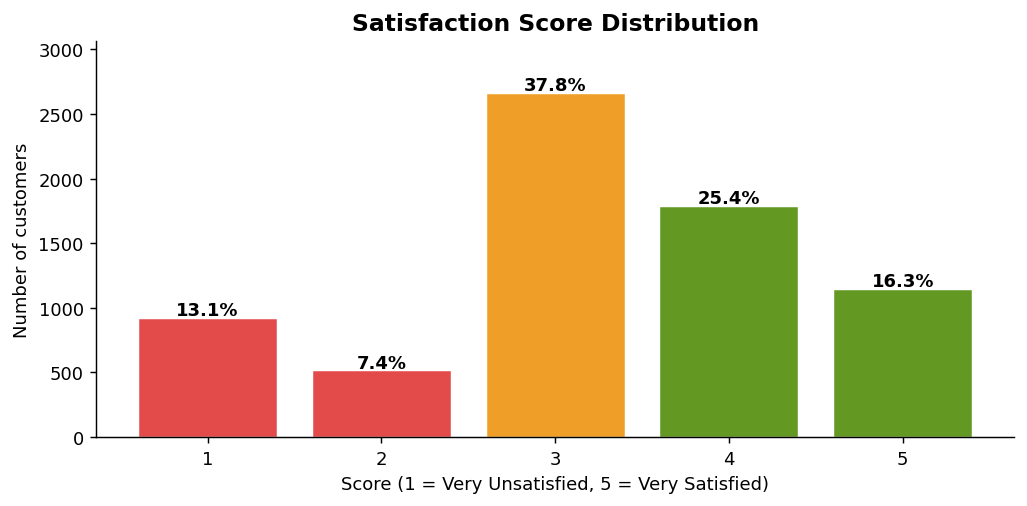

In [5]:
# ── CELL 07 : Satisfaction Score distribution ─────────────
# Before mapping, we analyze the raw distribution to
# understand the data and justify our mapping decision.
# ============================================================

score_counts = df['Satisfaction Score'].value_counts().sort_index()
score_pcts   = score_counts / len(df) * 100

print("=" * 55)
print("SATISFACTION SCORE DISTRIBUTION")
print("=" * 55)
print(f"  Null values : {df['Satisfaction Score'].isna().sum()}")
print()
for score, n in score_counts.items():
    bar = '█' * int(score_pcts[score] * 1.5)
    print(f"  Score {score} : {n:,}  ({score_pcts[score]:.1f}%)  {bar}")

# --- Visualization ---
fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['#E24B4A', '#E24B4A', '#EF9F27', '#639922', '#639922']
bars    = ax.bar(score_counts.index, score_counts.values,
                 color=colors, edgecolor='white', linewidth=0.8)

for bar, pct in zip(bars, score_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'{pct:.1f}%', ha='center',
            fontsize=10, fontweight='bold')

ax.set_title('Satisfaction Score Distribution',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Score (1 = Very Unsatisfied, 5 = Very Satisfied)')
ax.set_ylabel('Number of customers')
ax.set_ylim(0, score_counts.max() * 1.15)
plt.tight_layout()
plt.show()

### NPS Mapping Decision

**Artefact baseline mapping :**
- Score ≤ 3 → Detractor | Score 4 → Passive | Score 5 → Promoter

**Our adjusted mapping (retained) :**
- Score 1-2 → Detractor | Score 3 → Passive | Score 4-5 → Promoter

**Justification :**

1. **Score 3 represents 37.8% of the base** — the largest single group.
   Labeling it as Detractor would produce 58.3% Detractors, an unrealistic
   majority for a telecom operator.

2. **Score 3 semantically means Neutral**, which aligns with the NPS
   definition of Passive (NPS 7-8) : neither satisfied nor dissatisfied.

3. **Empirical validation via Churn Score** : the average Churn Score
   for Score 3 customers is 55.0, close to satisfied customers (50.2),
   far from truly dissatisfied scores 1-2 (81.9). Score 3 behaves
   as Passive, not Detractor.

4. **More balanced distribution** : 20.4% / 37.8% / 41.7%
   vs Artefact baseline which yields 58.3% / 25.4% / 16.3%.

> The challenge explicitly encourages challenging the baseline mapping.
> We do so with empirical evidence, not opinion.

MAPPING SENSITIVITY — Distribution Comparison

Class           Artefact baseline     Our mapping
--------------------------------------------------
  Detractor    :               58.3%           20.4%
  Passive      :               25.4%           37.8%
  Promoter     :               16.3%           41.7%

Key insight :
  Artefact baseline → Detractor = 58.3%
  Our mapping       → Detractor = 20.4%

  Baseline produces an unrealistic 58% Detractor majority.
  Score 3 (37.8% of base) semantically means Neutral,
  not Detractor — empirically confirmed by Churn Score (55.0 vs 81.9).

  Our mapping is more business-realistic and empirically justified.
  The downstream model trained on our mapping captures genuine
  dissatisfaction signals rather than artificial majority bias.



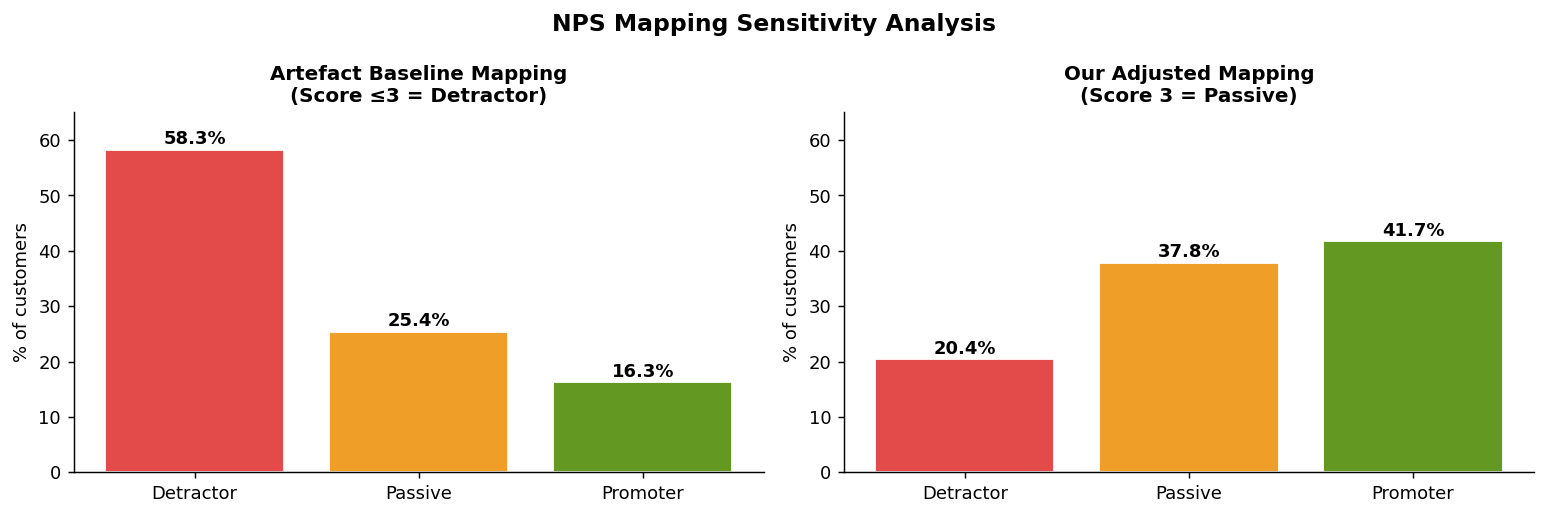

In [6]:
# ── CELL 09b : Mapping sensitivity analysis ───────────────
# The challenge asks us to discuss how sensitive the model
# is to the NPS mapping choice.
# We compare our mapping vs the Artefact baseline mapping.
# ============================================================

# --- Artefact baseline mapping ---
def map_nps_baseline(score):
    if score <= 3:   return 'Detractor'
    elif score == 4: return 'Passive'
    else:            return 'Promoter'

# --- Our mapping ---
def map_nps_ours(score):
    if score <= 2:   return 'Detractor'
    elif score == 3: return 'Passive'
    else:            return 'Promoter'

# --- Compare distributions ---
baseline_dist = df['Satisfaction Score'].apply(
    map_nps_baseline).value_counts(normalize=True) * 100
our_dist = df['Satisfaction Score'].apply(
    map_nps_ours).value_counts(normalize=True) * 100

print("=" * 60)
print("MAPPING SENSITIVITY — Distribution Comparison")
print("=" * 60)
print(f"\n{'Class':12s} {'Artefact baseline':>20s} {'Our mapping':>15s}")
print("-" * 50)
for label in ['Detractor', 'Passive', 'Promoter']:
    b = baseline_dist.get(label, 0)
    o = our_dist.get(label, 0)
    print(f"  {label:12s} : {b:>18.1f}%  {o:>13.1f}%")

print(f"""
Key insight :
  Artefact baseline → Detractor = {baseline_dist.get('Detractor',0):.1f}%
  Our mapping       → Detractor = {our_dist.get('Detractor',0):.1f}%

  Baseline produces an unrealistic {baseline_dist.get('Detractor',0):.0f}% Detractor majority.
  Score 3 (37.8% of base) semantically means Neutral,
  not Detractor — empirically confirmed by Churn Score (55.0 vs 81.9).

  Our mapping is more business-realistic and empirically justified.
  The downstream model trained on our mapping captures genuine
  dissatisfaction signals rather than artificial majority bias.
""")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#E24B4A', '#EF9F27', '#639922']
labels = ['Detractor', 'Passive', 'Promoter']

axes[0].bar(labels,
            [baseline_dist.get(l, 0) for l in labels],
            color=colors, edgecolor='white')
axes[0].set_title('Artefact Baseline Mapping\n(Score ≤3 = Detractor)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('% of customers')
axes[0].set_ylim(0, 65)
for i, l in enumerate(labels):
    axes[0].text(i, baseline_dist.get(l, 0) + 1,
                 f"{baseline_dist.get(l, 0):.1f}%",
                 ha='center', fontweight='bold')

axes[1].bar(labels,
            [our_dist.get(l, 0) for l in labels],
            color=colors, edgecolor='white')
axes[1].set_title('Our Adjusted Mapping\n(Score 3 = Passive)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('% of customers')
axes[1].set_ylim(0, 65)
for i, l in enumerate(labels):
    axes[1].text(i, our_dist.get(l, 0) + 1,
                 f"{our_dist.get(l, 0):.1f}%",
                 ha='center', fontweight='bold')

plt.suptitle('NPS Mapping Sensitivity Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Section 2.2 — Applying the NPS Mapping

Encoding :
- `NPS_Category` : ordered categorical (Detractor < Passive < Promoter)
- `NPS_Code` : integer encoding (0 < 1 < 2) — used for modeling

NPS CATEGORY DISTRIBUTION
  Detractor    : 1,440 (20.4%)  ████████████████████
  Passive      : 2,665 (37.8%)  █████████████████████████████████████
  Promoter     : 2,938 (41.7%)  █████████████████████████████████████████

  Class imbalance ratio : 2.0x (Promoter vs Detractor)
  → Moderate imbalance — handled with class_weight='balanced' in modeling


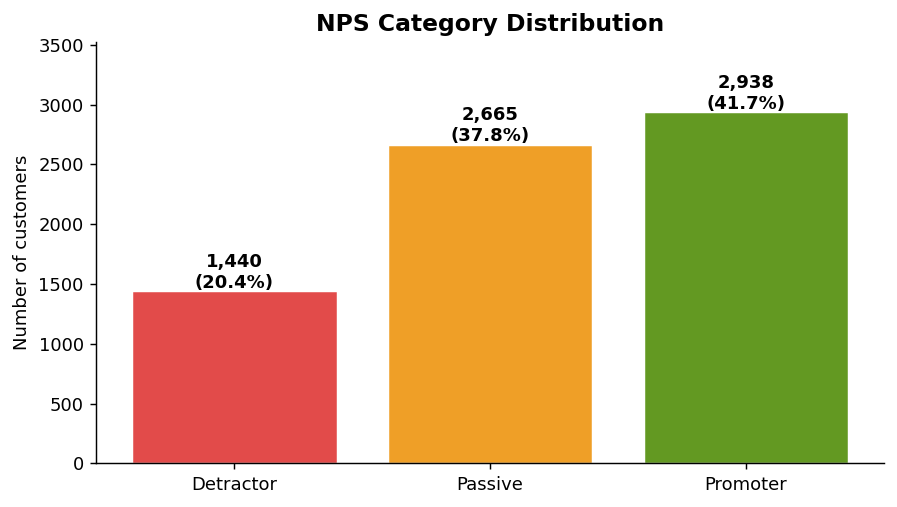

In [7]:
# ── CELL 09 : Build NPS target variable ───────────────────
# Mapping : Score 1-2 → Detractor
#           Score 3   → Passive
#           Score 4-5 → Promoter
#
# NPS_Category : ordered categorical (Detractor < Passive < Promoter)
# NPS_Code     : integer encoding  (0 < 1 < 2)
# ============================================================

def map_nps(score):
    if score <= 2:   return 'Detractor'
    elif score == 3: return 'Passive'
    else:            return 'Promoter'

df['NPS_Category'] = df['Satisfaction Score'].apply(map_nps)
df['NPS_Category'] = pd.Categorical(
    df['NPS_Category'],
    categories=NPS_ORDER,
    ordered=True
)
df['NPS_Code'] = df['NPS_Category'].map(NPS_MAP)

# --- Distribution ---
nps_counts = df['NPS_Category'].value_counts()[NPS_ORDER]
nps_pcts   = nps_counts / len(df) * 100

print("=" * 55)
print("NPS CATEGORY DISTRIBUTION")
print("=" * 55)
for label in NPS_ORDER:
    bar = '█' * int(nps_pcts[label])
    print(f"  {label:12s} : {nps_counts[label]:,} "
          f"({nps_pcts[label]:.1f}%)  {bar}")

print(f"\n  Class imbalance ratio : "
      f"{nps_pcts.max()/nps_pcts.min():.1f}x "
      f"({nps_pcts.idxmax()} vs {nps_pcts.idxmin()})")
print(f"  → Moderate imbalance — handled with "
      f"class_weight='balanced' in modeling")

# --- Visualization ---
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(NPS_ORDER,
              [nps_counts[l] for l in NPS_ORDER],
              color=[NPS_COLORS[l] for l in NPS_ORDER],
              edgecolor='white', linewidth=0.8)

for bar, label in zip(bars, NPS_ORDER):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{nps_counts[label]:,}\n({nps_pcts[label]:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('NPS Category Distribution', fontsize=13,
             fontweight='bold')
ax.set_ylabel('Number of customers')
ax.set_ylim(0, nps_counts.max() * 1.2)
plt.tight_layout()
plt.show()

---
## Section 3 — Data Leakage Management

The `status.xlsx` file contains several columns that would cause **data leakage**
if included as model features — they contain information unavailable at prediction
time, or are directly derived from the target variable.

> **Leakage** means the model would learn from information it cannot have in
> production, producing artificially inflated metrics with no real-world value.

### Section 3.1 — Identifying and Isolating Leakage Columns

Seven columns from `status.xlsx` are excluded from all model features.
We provide mathematical proof of leakage via Churn Score correlation.

In [8]:
# ── CELL 11 : Identify and isolate leakage columns ────────
# These columns are excluded from ALL model features.
# They are kept in a separate dataframe for reference only.
# ============================================================

LEAKAGE_COLS = [
    'Churn Score',     # IBM-calculated score using same signals
                       # as our features — circular reference
    'Churn Value',     # Binary churn flag — future information
    'Churn Label',     # Text version of Churn Value
    'Customer Status', # Directly states Churned/Stayed/Joined
    'CLTV',            # Lifetime value incorporating churn signals
    'Churn Category',  # Reason for churn — post-event information
    'Churn Reason',    # Detailed churn reason — post-event
]

# --- Keep leakage columns for reference only ---
df_leakage = df[['Customer ID'] +
                [c for c in LEAKAGE_COLS if c in df.columns]].copy()

# --- Proof of leakage : Churn Score vs NPS ---
print("=" * 55)
print("LEAKAGE PROOF — Churn Score vs NPS Category")
print("=" * 55)
churn_by_nps = df.groupby('NPS_Category')['Churn Score'].mean()
for label in NPS_ORDER:
    print(f"  {label:12s} : avg Churn Score = "
          f"{churn_by_nps[label]:.2f}")

print(f"\n  Gap Detractor vs Promoter : "
      f"{churn_by_nps['Detractor'] - churn_by_nps['Promoter']:.1f} points")
print(f"  → Churn Score is a near-perfect proxy for NPS")
print(f"  → Including it would inflate metrics artificially")

# --- Churn rate validation (post-hoc only) ---
print("\n" + "=" * 55)
print("CHURN RATE BY NPS CLASS (post-hoc validation)")
print("=" * 55)
churn_rate = df.groupby('NPS_Category')['Churn Value'].mean() * 100
for label in NPS_ORDER:
    print(f"  {label:12s} : {churn_rate[label]:.1f}% churn rate")

print(f"""
  Important observation :
  The perfect separation (Detractor=100%, Promoter=0%) reveals
  that IBM assigned Satisfaction Scores AFTER observing churn.
  Scores 1-2 → exclusively churned customers.
  Scores 4-5 → exclusively retained customers.
  Score 3    → the only genuinely mixed group.

  This is a known dataset limitation — acknowledged and
  documented. It does not invalidate our model but must
  be disclosed before production deployment.
""")

# --- Build clean modeling dataset ---
EXCLUDE_COLS = LEAKAGE_COLS + [
    'Customer ID', 'Count', 'Quarter',
    'Lat Long', 'Country', 'State', 'City',
    'Satisfaction Score',  # source of target — not a feature
    'NPS_Code',            # encoding of target
]

df_model = df.drop(
    columns=[c for c in EXCLUDE_COLS if c in df.columns]
).copy()

print("=" * 55)
print("CLEAN DATASET FOR MODELING")
print("=" * 55)
print(f"  Shape : {df_model.shape[0]:,} rows × "
      f"{df_model.shape[1]} columns")
print(f"  Leakage columns removed : {len(LEAKAGE_COLS)}")

LEAKAGE PROOF — Churn Score vs NPS Category
  Detractor    : avg Churn Score = 81.86
  Passive      : avg Churn Score = 55.00
  Promoter     : avg Churn Score = 50.23

  Gap Detractor vs Promoter : 31.6 points
  → Churn Score is a near-perfect proxy for NPS
  → Including it would inflate metrics artificially

CHURN RATE BY NPS CLASS (post-hoc validation)
  Detractor    : 100.0% churn rate
  Passive      : 16.1% churn rate
  Promoter     : 0.0% churn rate

  Important observation :
  The perfect separation (Detractor=100%, Promoter=0%) reveals
  that IBM assigned Satisfaction Scores AFTER observing churn.
  Scores 1-2 → exclusively churned customers.
  Scores 4-5 → exclusively retained customers.
  Score 3    → the only genuinely mixed group.

  This is a known dataset limitation — acknowledged and
  documented. It does not invalidate our model but must
  be disclosed before production deployment.

CLEAN DATASET FOR MODELING
  Shape : 7,043 rows × 39 columns
  Leakage columns removed : 

### Section 3.2 — NPS Proxy Limitation

**The Satisfaction Score (1-5) is not a true NPS (0-10).**

| Dimension | True NPS | Our proxy (Satisfaction Score) |
|---|---|---|
| Scale | 0 to 10 | 1 to 5 |
| Question | "Would you recommend us?" | "How satisfied are you?" |
| Collection | Post-interaction survey | IBM-assigned (post-churn) |
| Availability | 15% respondents | 100% of customers (IBM dataset) |

**Known consequences for our model :**

1. **Scale compression** : 5 satisfaction levels map to 3 NPS classes.
   Nuance within each class is lost — a Score 4 customer nearly at
   Score 5 is treated identically to one barely above Score 3.

2. **Question framing** : Satisfaction ≠ Recommendation intent.
   A customer can be satisfied but still not recommend (Passive behavior).
   Our proxy conflates these two distinct signals.

3. **Post-event assignment** : IBM assigned scores after observing churn
   (Detractor = 100% churned, Promoter = 0% churned). In a real NPS
   survey, dissatisfied customers do not always churn immediately —
   creating a more ambiguous, realistic signal.

**Impact on modeling :**
Our model learns behavioral patterns (contract type, tenure, charges)
that correlate with IBM's post-hoc satisfaction assignment.
In production with a real NPS survey, the signal would be noisier
and model performance would likely be lower than our test QWK of 0.449.
This must be disclosed before production deployment.

---
## Section 4 — Exploratory Data Analysis

We analyze how each variable differs across NPS classes to identify
predictive signals and guide feature engineering decisions.

**Key questions :**
- Which numerical variables separate Detractors from Promoters ?
- Which categorical variables show the strongest Detractor rate gap ?
- Are there demographic patterns relevant to fairness auditing ?

### Section 4.1 — Numerical Variables Analysis

For each numerical variable, we compare mean values across NPS classes
to identify predictive signals for feature engineering.

MEAN VALUES BY NPS CLASS
NPS_Category                 Detractor  Passive  Promoter
Age                              49.78    45.95     45.41
Tenure in Months                 18.17    36.02     36.06
Monthly Charge                   74.97    66.23     58.42
Total Charges                  1566.72  2599.94   2340.30
Total Revenue                  2008.00  3433.74   3175.19
Number of Referrals               0.56     2.25      2.37
Total Long Distance Charges     435.58   828.79    830.48
Avg Monthly GB Download          22.41    21.50     18.69
Number of Dependents              0.12     0.53      0.58
Population                    23801.22 21513.89  21892.77


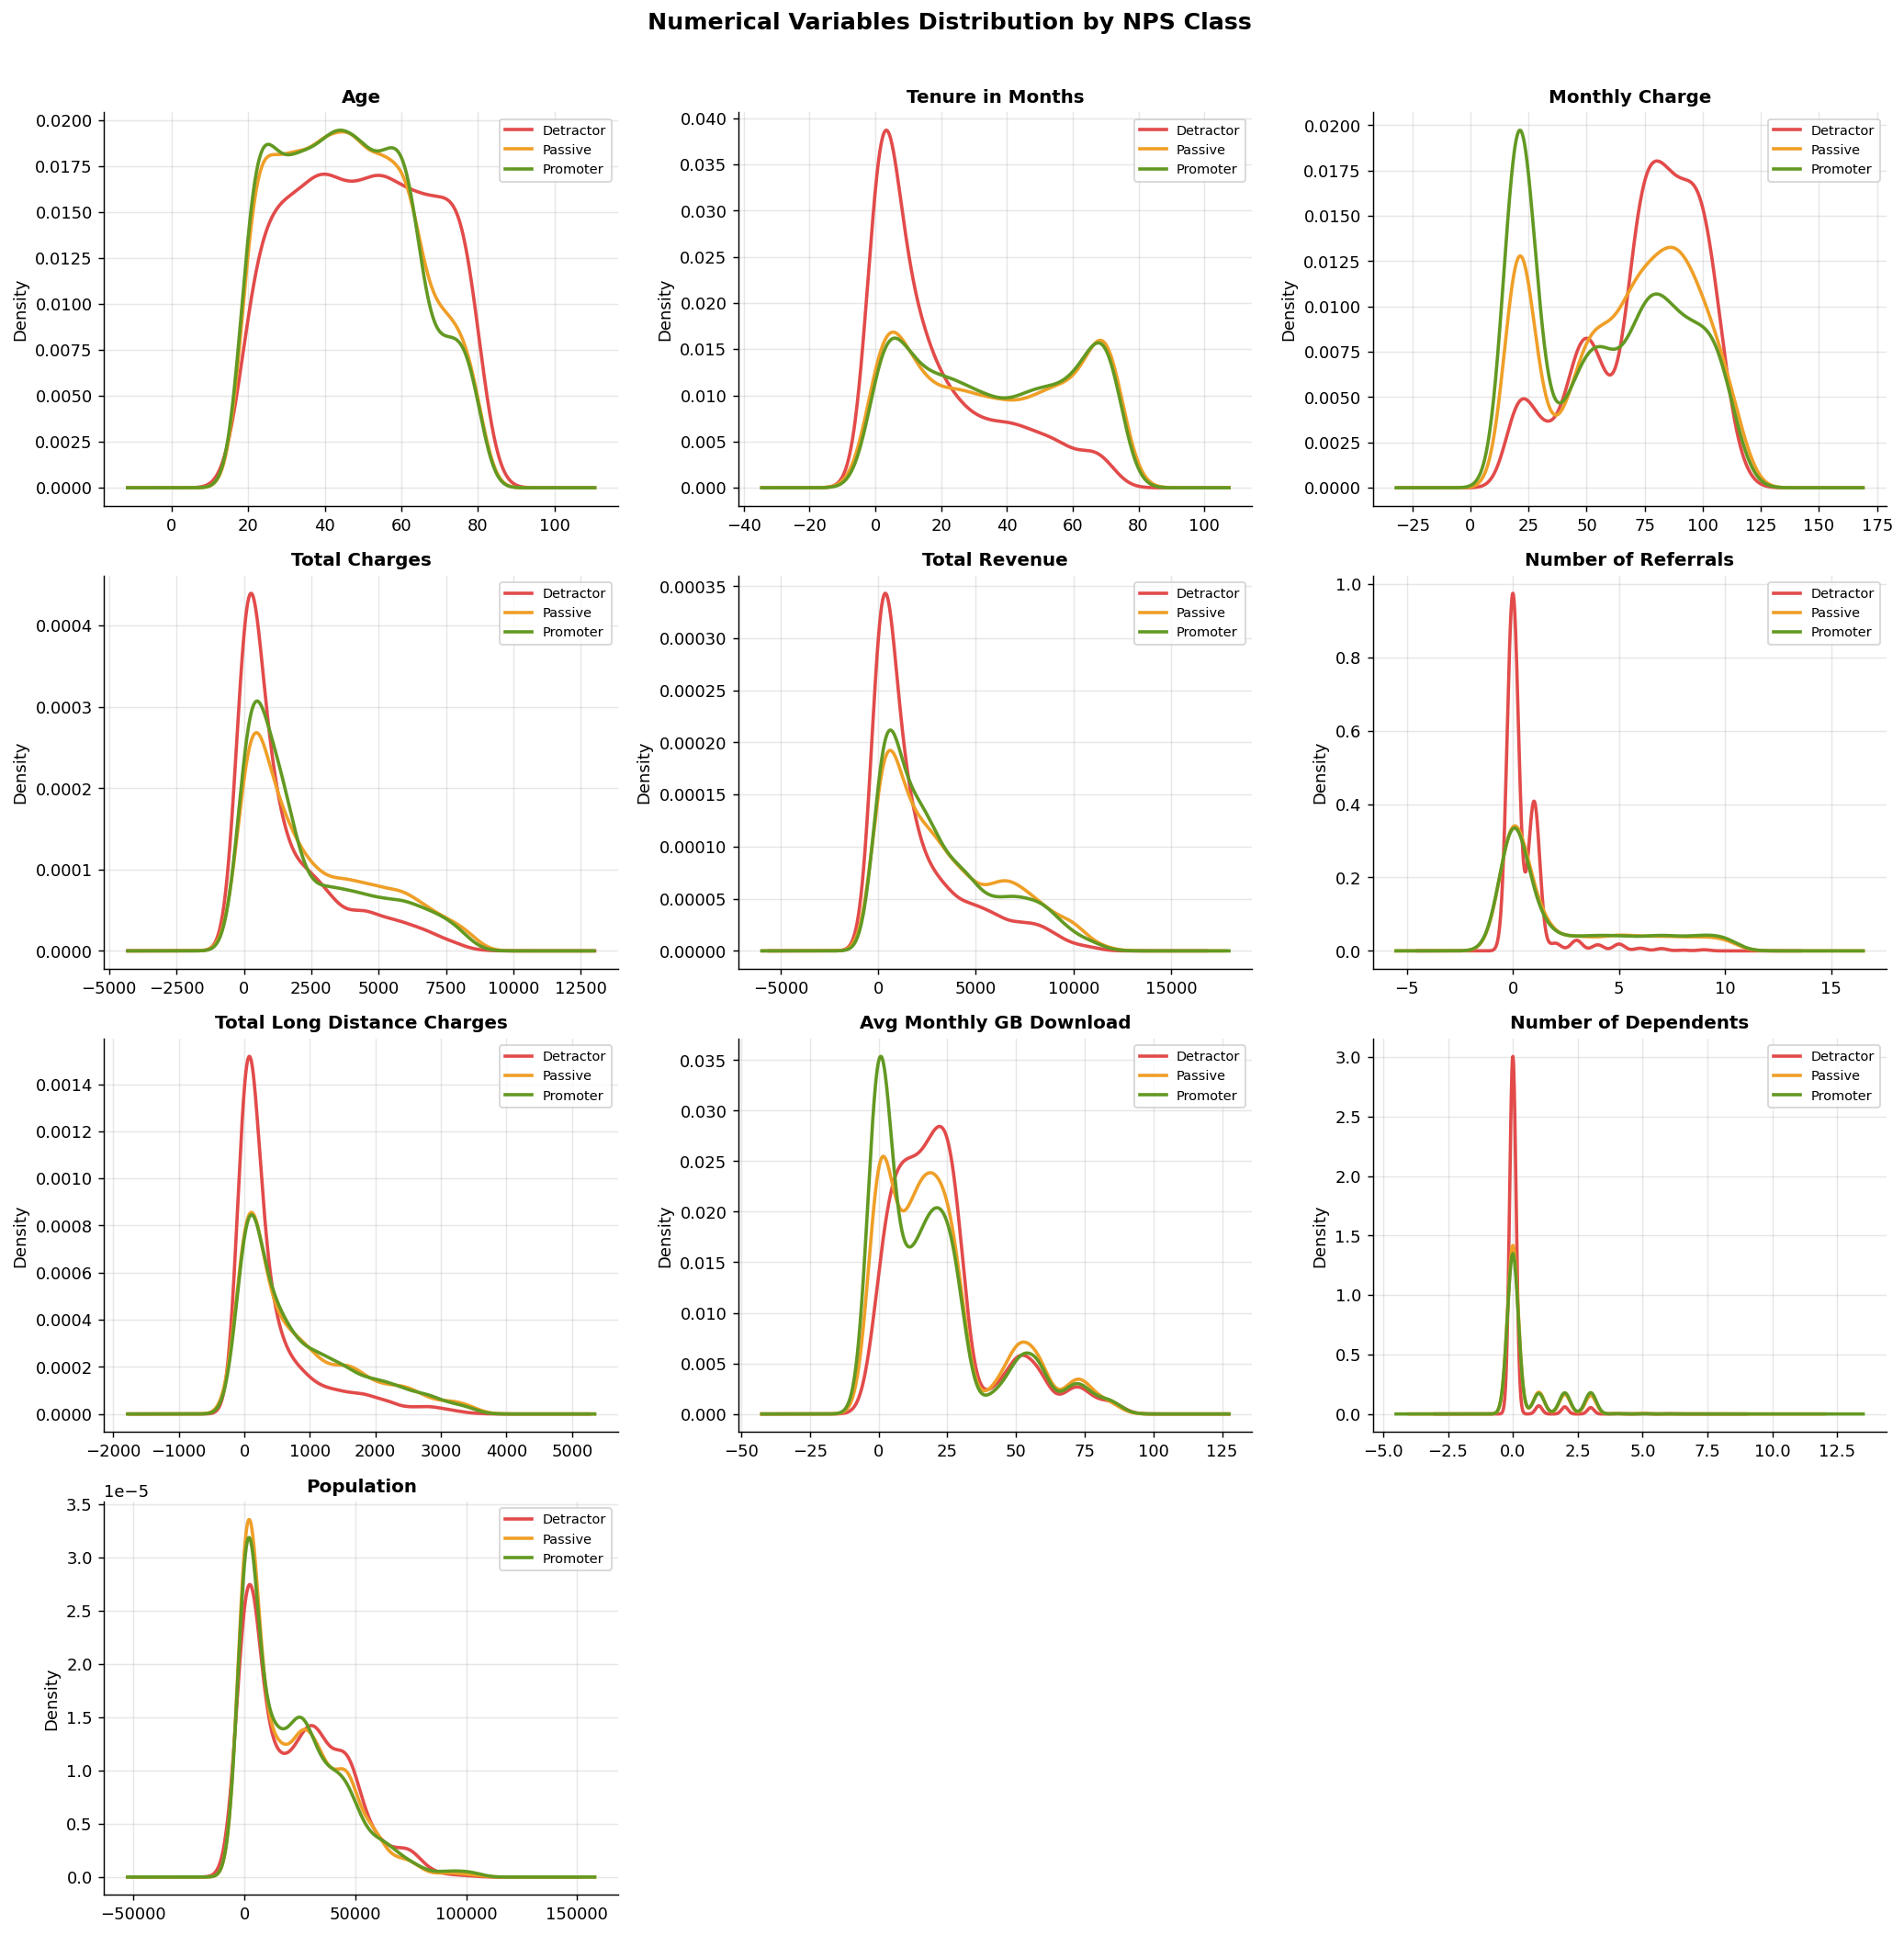

In [9]:
# ── CELL 13 : Numerical variables by NPS class ────────────
# Goal : identify which numerical variables show strong
# signal across Detractor / Passive / Promoter classes.
# ============================================================

# Note : df_model is defined in Section 3 (CELL 11 — leakage management)
# Ensure cells are run in order before executing this cell.

NUM_COLS = [
    'Age', 'Tenure in Months', 'Monthly Charge',
    'Total Charges', 'Total Revenue',
    'Number of Referrals', 'Total Long Distance Charges',
    'Avg Monthly GB Download', 'Number of Dependents',
    'Population'
]

# --- Mean values by NPS class ---
print("=" * 65)
print("MEAN VALUES BY NPS CLASS")
print("=" * 65)
summary = df_model.groupby(
    'NPS_Category', observed=True)[NUM_COLS].mean().round(2)
print(summary.T.to_string())

# --- Visualization : KDE plots ---
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    for label in NPS_ORDER:
        subset = df_model[df_model['NPS_Category'] == label][col].dropna()
        subset.plot(kind='kde', ax=ax, label=label,
                   color=NPS_COLORS[label], linewidth=2)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables Distribution by NPS Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Section 4.2 — Categorical Variables Analysis

For each categorical variable, we compute the Detractor rate per modality.
Delta = max - min rate within the variable — our signal strength measure.

In [10]:
# ── CELL 14 : Categorical variables by NPS class ──────────
# Goal : identify which categorical variables show the
# strongest Detractor rate gap across their modalities.
# Delta = max - min Detractor rate within the variable.
# ============================================================

CAT_COLS = [
    'Contract', 'Internet Type', 'Payment Method', 'Offer',
    'Senior Citizen', 'Married', 'Dependents',
    'Online Security', 'Premium Tech Support',
    'Referred a Friend', 'Gender', 'Phone Service'
]

# --- Detractor rate by modality ---
print("=" * 65)
print("DETRACTOR RATE BY CATEGORICAL VARIABLE")
print("=" * 65)
print("(Higher = more Detractors in this group)\n")

signal_summary = []
for col in CAT_COLS:
    if col not in df_model.columns:
        continue
    rates = df_model.groupby(col)['NPS_Category'].apply(
        lambda x: (x == 'Detractor').mean() * 100
    ).round(1)
    delta = rates.max() - rates.min()
    signal = ("VERY STRONG" if delta > 20
              else "STRONG" if delta > 10
              else "MODERATE" if delta > 5
              else "WEAK")
    signal_summary.append({
        'Variable': col,
        'Delta'   : round(delta, 1),
        'Signal'  : signal
    })
    print(f"  {col} (delta={delta:.1f} pts — {signal})")
    for mod, rate in rates.sort_values(ascending=False).items():
        bar = '█' * int(rate / 3)
        print(f"    {str(mod):25s} : {rate:.1f}%  {bar}")
    print()

# --- Signal summary table ---
print("=" * 65)
print("SIGNAL STRENGTH SUMMARY")
print("=" * 65)
df_signal = pd.DataFrame(signal_summary).sort_values(
    'Delta', ascending=False)
for _, row in df_signal.iterrows():
    print(f"  {row['Variable']:30s} : "
          f"delta={row['Delta']:5.1f} pts  {row['Signal']}")

DETRACTOR RATE BY CATEGORICAL VARIABLE
(Higher = more Detractors in this group)

  Contract (delta=34.2 pts — VERY STRONG)
    Month-to-Month            : 35.8%  ███████████
    One Year                  : 7.5%  ██
    Two Year                  : 1.6%  

  Internet Type (delta=16.3 pts — STRONG)
    Fiber Optic               : 31.2%  ██████████
    Cable                     : 21.3%  ███████
    DSL                       : 14.9%  ████

  Payment Method (delta=18.8 pts — STRONG)
    Mailed Check              : 29.9%  █████████
    Bank Withdrawal           : 26.1%  ████████
    Credit Card               : 11.1%  ███

  Offer (delta=34.3 pts — VERY STRONG)
    Offer E                   : 39.1%  █████████████
    Offer D                   : 21.8%  ███████
    Offer C                   : 16.1%  █████
    Offer B                   : 10.1%  ███
    Offer A                   : 4.8%  █

  Senior Citizen (delta=13.5 pts — STRONG)
    Yes                       : 31.8%  ██████████
    No          

### EDA Key Findings

#### Numerical variables — top signals

| Variable | Detractor | Promoter | Gap | Insight |
|---|---|---|---|---|
| Tenure in Months | 18.17 | 36.06 | 18 months | New customers detract most |
| Number of Referrals | 0.56 | 2.37 | 4.2x | Referrals = loyalty proxy |
| Monthly Charge | $74.97 | $58.42 | $16.55 | High charge = poor value perception |
| Total Long Distance | $435 | $830 | $395 | Detractors less engaged |
| Number of Dependents | 0.12 | 0.58 | 5x | Family customers more loyal |

#### Categorical variables — top signals

| Variable | Low Detractor | High Detractor | Delta | Decision |
|---|---|---|---|---|
| Contract | Two Year : 1.6% | Month-to-Month : 35.8% | 34 pts | Feature : `is_month_to_month` |
| Offer | Offer A : 4.8% | Offer E : 39.1% | 34 pts | Feature : `is_offer_E` |
| Dependents | Yes : 5.2% | No : 25.0% | 20 pts | Feature : `has_family` |
| Internet Type | DSL : 14.9% | Fiber : 31.2% | 16 pts | Feature : `has_fiber` |
| Senior Citizen | No : 18.3% | Yes : 31.8% | 13 pts | Feature : `is_senior` (+ fairness) |
| Premium Support | Yes : 12.2% | No : 23.8% | 12 pts | Feature : `has_premium_support` |
| Gender | Female : 20.3% | Male : 20.6% | 0.3 pts | **No signal — fairness audit only** |
| Phone Service | No : 19.9% | Yes : 20.5% | 0.6 pts | **No signal — excluded** |

---
## Section 5 — Feature Engineering

We create derived features based **exclusively on signals confirmed during EDA**.
Each feature is justified by its Detractor rate gap or mean difference across
NPS classes.

**Principles :**
- No feature created without EDA justification
- Binary features preferred over raw categoricals (simpler, interpretable)
- Multicollinearity checked after creation (threshold : correlation > 0.80)

### Section 5.1 — Creating Derived Features

12 binary/ratio features derived from EDA-confirmed signals.
Each feature is tagged with its EDA justification (Detractor rate delta
or mean difference across NPS classes).

In [11]:
# ── CELL 17 : Feature engineering ─────────────────────────
# 12 derived features created from EDA-confirmed signals.
# Each feature is justified by its Detractor rate gap.
# ============================================================

df_feat = df_model.copy()

# --- 1. Contract risk (delta 34 pts) ---
df_feat['is_month_to_month'] = (
    df_feat['Contract'] == 'Month-to-Month'
).astype(int)

# --- 2. New customer (Tenure: 18m vs 36m) ---
df_feat['is_new_customer'] = (
    df_feat['Tenure in Months'] <= 12
).astype(int)

# --- 3. Fiber internet (delta 16 pts) ---
df_feat['has_fiber'] = (
    df_feat['Internet Type'] == 'Fiber Optic'
).astype(int)

# --- 4. Premium tech support (delta 12 pts) ---
df_feat['has_premium_support'] = (
    df_feat['Premium Tech Support'] == 'Yes'
).astype(int)

# --- 5. Family customer (delta 20 pts) ---
df_feat['has_family'] = (
    df_feat['Dependents'] == 'Yes'
).astype(int)

# --- 6. Senior citizen (delta 13 pts — also fairness) ---
df_feat['is_senior'] = (
    df_feat['Senior Citizen'] == 'Yes'
).astype(int)

# --- 7. Has referred at least once (delta 9 pts) ---
df_feat['has_referred'] = (
    df_feat['Number of Referrals'] > 0
).astype(int)

# --- 8. Offer E flag (delta 34 pts) ---
df_feat['is_offer_E'] = (
    df_feat['Offer'] == 'Offer E'
).astype(int)

# --- 9. Auto-pay (delta 19 pts) ---
df_feat['is_auto_pay'] = df_feat['Payment Method'].isin(
    ['Bank Withdrawal', 'Credit Card']
).astype(int)

# --- 10. Number of services subscribed ---
service_cols = [
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Multiple Lines'
]
df_feat['nb_services'] = df_feat[service_cols].apply(
    lambda row: sum(1 for v in row if v == 'Yes'), axis=1
)

# --- 11. Charge per service (value perception proxy) ---
df_feat['charge_per_service'] = (
    df_feat['Monthly Charge'] / (df_feat['nb_services'] + 1)
)

# --- 12. Is married (delta 9 pts) ---
df_feat['is_married'] = (
    df_feat['Married'] == 'Yes'
).astype(int)

# --- Summary ---
new_features = [
    'is_month_to_month', 'is_new_customer', 'has_fiber',
    'has_premium_support', 'has_family', 'is_senior',
    'has_referred', 'is_offer_E', 'is_auto_pay',
    'nb_services', 'charge_per_service', 'is_married'
]

print("=" * 55)
print("FEATURES CREATED")
print("=" * 55)
for f in new_features:
    dtype = str(df_feat[f].dtype)
    ex    = df_feat[f].iloc[0]
    print(f"  {f:25s} : {dtype:8s} | example = {ex}")

print(f"\n  Total new features : {len(new_features)}")
print(f"  Dataset shape      : {df_feat.shape}")

FEATURES CREATED
  is_month_to_month         : int64    | example = 1
  is_new_customer           : int64    | example = 1
  has_fiber                 : int64    | example = 0
  has_premium_support       : int64    | example = 0
  has_family                : int64    | example = 0
  is_senior                 : int64    | example = 1
  has_referred              : int64    | example = 0
  is_offer_E                : int64    | example = 0
  is_auto_pay               : int64    | example = 1
  nb_services               : int64    | example = 2
  charge_per_service        : float64  | example = 13.216666666666667
  is_married                : int64    | example = 0

  Total new features : 12
  Dataset shape      : (7043, 51)


### Section 5.2 — Correlation Analysis & Multicollinearity Check

We rank all candidate features by their Pearson correlation with the
NPS target, then remove pairs with inter-feature correlation > 0.80.

In [12]:
# ── CELL 18 : Correlation analysis & final feature selection
# Goal : detect multicollinearity between features and rank
# them by predictive power on NPS target.
#
# Rules :
#   - Correlation with NPS > 0.07  → candidate feature
#   - Inter-feature correlation > 0.80 → keep only one
# ============================================================

# --- All candidate numerical features ---
CANDIDATE_FEATURES = [
    'Tenure in Months', 'Monthly Charge',
    'Total Long Distance Charges', 'Total Charges',
    'Total Revenue', 'Number of Referrals',
    'Avg Monthly GB Download', 'Number of Dependents',
    'Age', 'Population',
    'is_month_to_month', 'is_new_customer', 'has_fiber',
    'has_premium_support', 'has_family', 'is_senior',
    'has_referred', 'is_offer_E', 'is_auto_pay',
    'nb_services', 'charge_per_service', 'is_married'
]

# --- Encode NPS as numeric for correlation ---
df_feat['NPS_numeric'] = df_feat['NPS_Category'].map(NPS_MAP)

corr_matrix = df_feat[CANDIDATE_FEATURES + ['NPS_numeric']].corr()

# --- Correlation with NPS target ---
print("=" * 65)
print("CORRELATION WITH NPS TARGET")
print("=" * 65)
corr_target = corr_matrix['NPS_numeric'].drop('NPS_numeric')
corr_sorted = corr_target.abs().sort_values(ascending=False)

for feat, val in corr_sorted.items():
    sign = '+' if corr_target[feat] > 0 else '-'
    bar  = '█' * int(val * 30)
    print(f"  {sign} {feat:35s} : {val:.3f}  {bar}")

# --- High inter-feature correlations ---
print("\n" + "=" * 65)
print("HIGH INTER-FEATURE CORRELATIONS (> 0.80) — MULTICOLLINEARITY")
print("=" * 65)
high_corr = []
cols = CANDIDATE_FEATURES
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = abs(corr_matrix.loc[cols[i], cols[j]])
        if val > 0.80:
            high_corr.append((cols[i], cols[j], round(val, 3)))

if not high_corr:
    print("  No pairs above 0.80")
else:
    for f1, f2, v in sorted(high_corr, key=lambda x: -x[2]):
        print(f"  {f1:35s} ↔ {f2:30s} : {v}")

CORRELATION WITH NPS TARGET
  - is_month_to_month                   : 0.343  ██████████
  + Tenure in Months                    : 0.238  ███████
  - has_fiber                           : 0.228  ██████
  - is_new_customer                     : 0.217  ██████
  - Monthly Charge                      : 0.207  ██████
  + Number of Referrals                 : 0.202  ██████
  - charge_per_service                  : 0.181  █████
  + has_family                          : 0.180  █████
  + Number of Dependents                : 0.164  ████
  + Total Long Distance Charges         : 0.153  ████
  - is_offer_E                          : 0.145  ████
  + Total Revenue                       : 0.123  ███
  - is_senior                           : 0.114  ███
  + Total Charges                       : 0.099  ██
  + has_referred                        : 0.089  ██
  - Age                                 : 0.088  ██
  + is_married                          : 0.088  ██
  + has_premium_support                 : 0.0

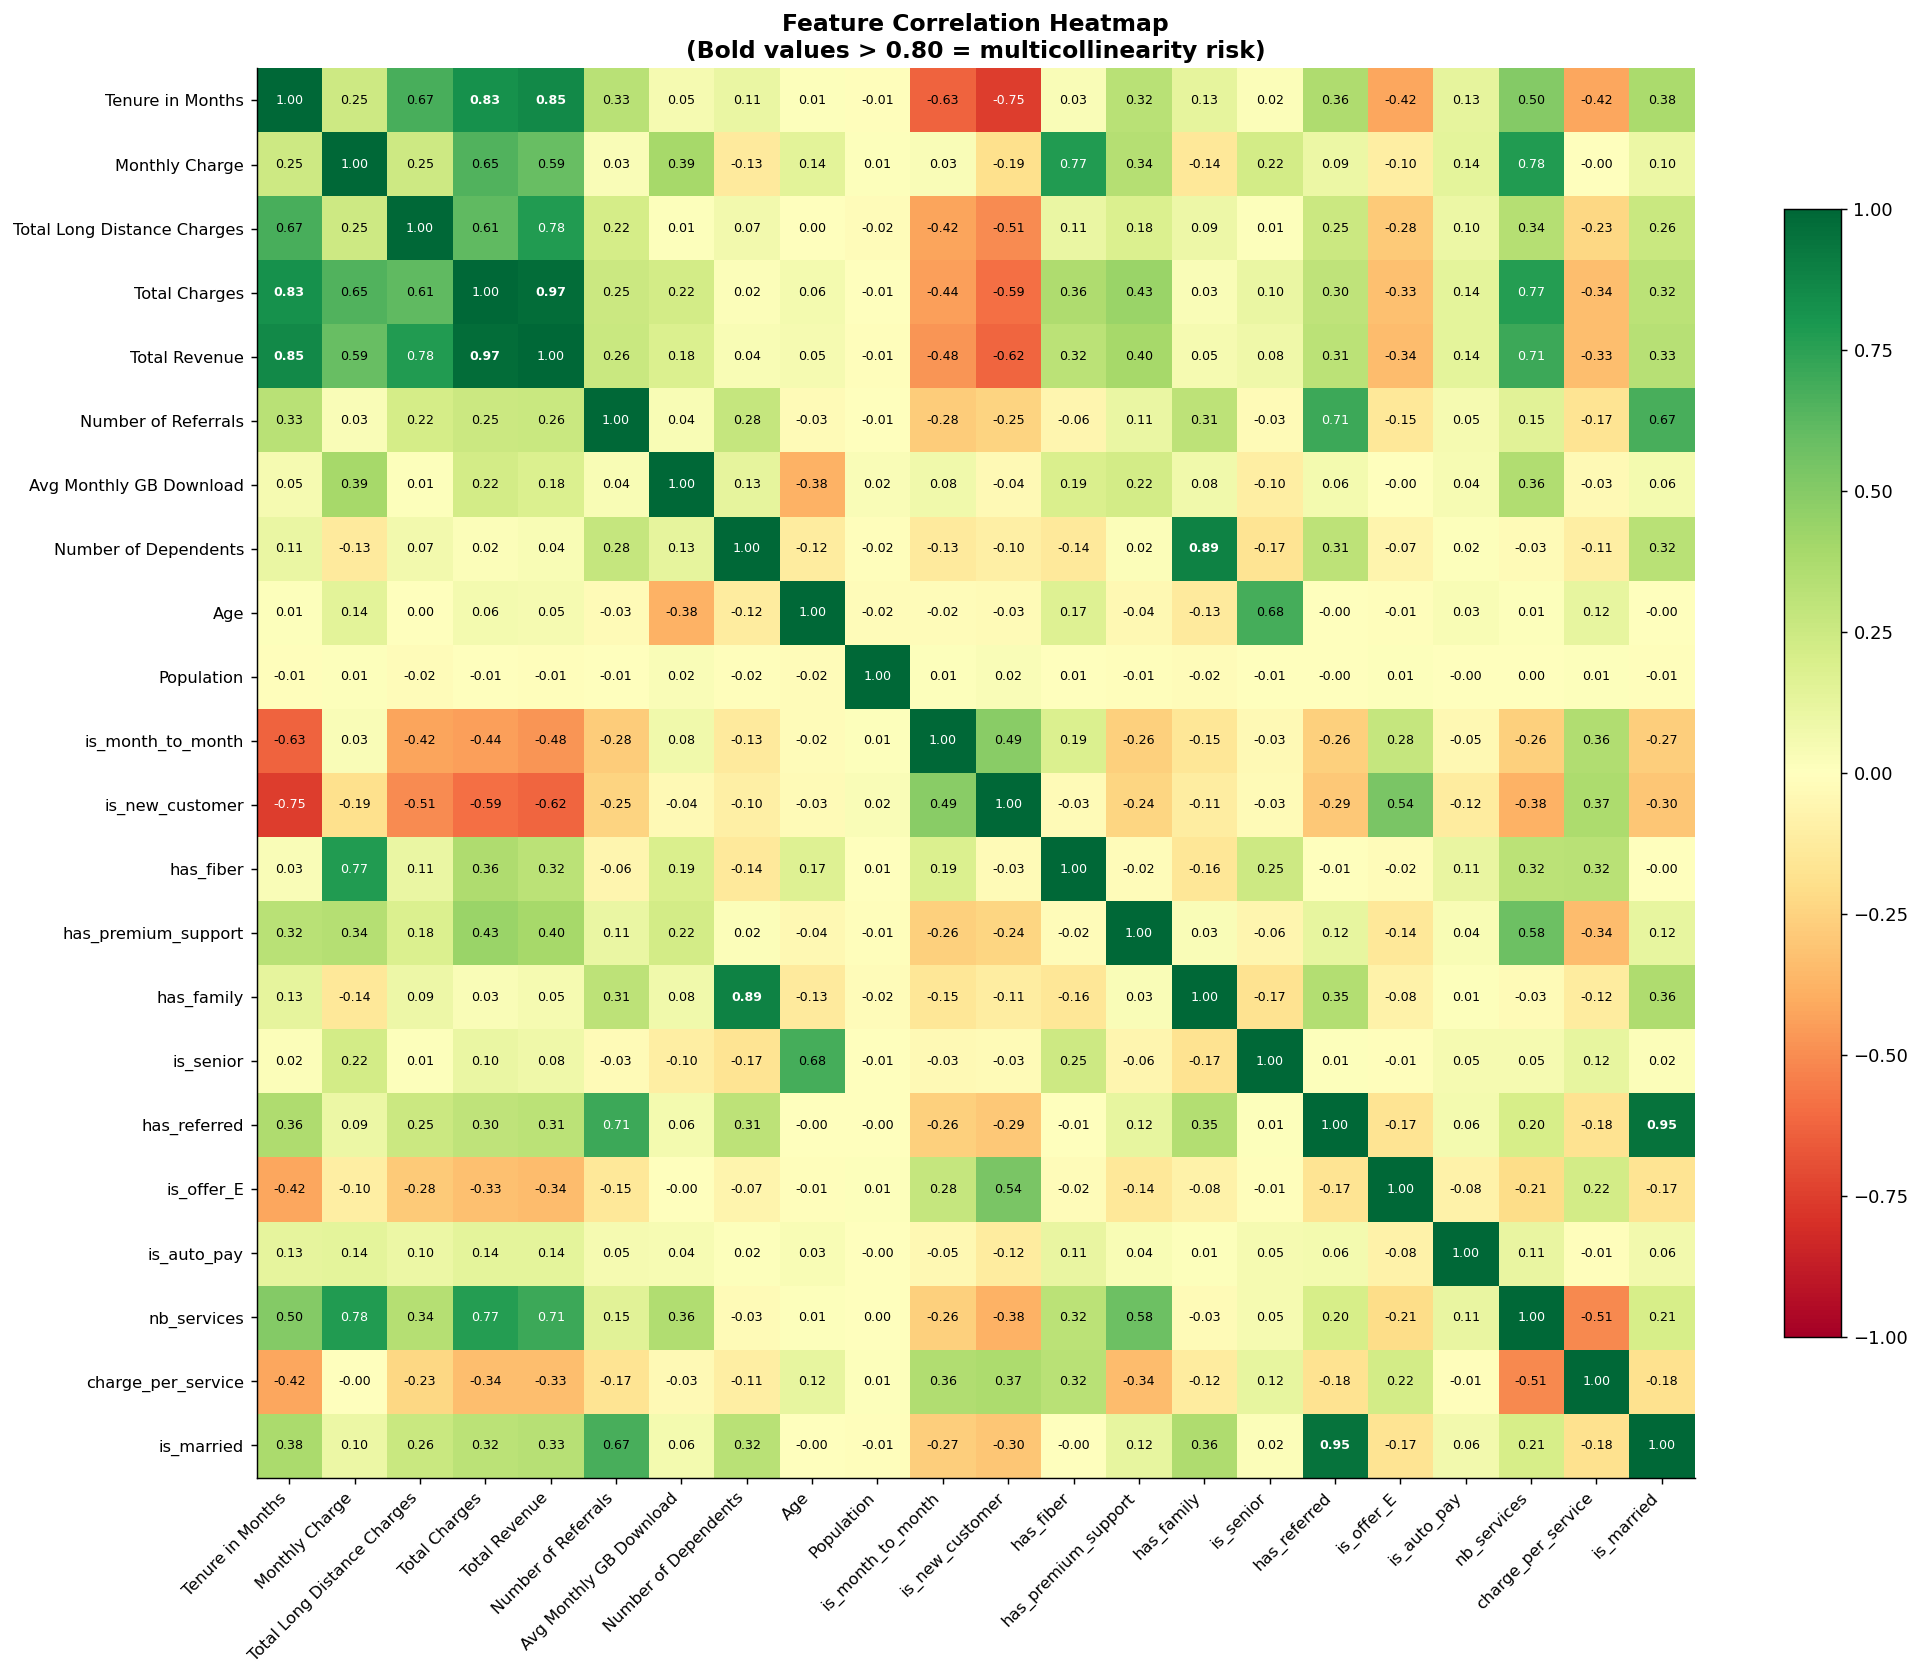

PAIRS WITH CORRELATION > 0.80
  Tenure in Months               ↔ Total Charges                  : 0.826
  Tenure in Months               ↔ Total Revenue                  : 0.853
  Total Charges                  ↔ Total Revenue                  : 0.972
  Number of Dependents           ↔ has_family                     : 0.888
  has_referred                   ↔ is_married                     : 0.950


In [13]:
# ── CELL 18b : Correlation heatmap ────────────────────────
# Visualize inter-feature correlations to identify
# multicollinearity at a glance.
# Pairs above 0.80 are highlighted — these are the pairs
# where we must keep only one feature.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# --- Compute correlation matrix on candidate features ---
corr_feat = df_feat[CANDIDATE_FEATURES].corr()

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(16, 13))

mask = np.zeros_like(corr_feat, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle

im = ax.imshow(corr_feat.values, cmap='RdYlGn',
               vmin=-1, vmax=1, aspect='auto')

# --- Add values ---
for i in range(len(corr_feat)):
    for j in range(len(corr_feat)):
        val = corr_feat.values[i, j]
        color = 'white' if abs(val) > 0.7 else 'black'
        # Highlight pairs above 0.80
        weight = 'bold' if abs(val) > 0.80 and i != j else 'normal'
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center',
                fontsize=7, color=color,
                fontweight=weight)

# --- Labels ---
ax.set_xticks(range(len(corr_feat)))
ax.set_yticks(range(len(corr_feat)))
ax.set_xticklabels(CANDIDATE_FEATURES, rotation=45,
                   ha='right', fontsize=9)
ax.set_yticklabels(CANDIDATE_FEATURES, fontsize=9)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature Correlation Heatmap\n'
             '(Bold values > 0.80 = multicollinearity risk)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150,
            bbox_inches='tight')
plt.show()

# --- Flag high correlations ---
print("=" * 55)
print("PAIRS WITH CORRELATION > 0.80")
print("=" * 55)
for i in range(len(corr_feat)):
    for j in range(i+1, len(corr_feat)):
        val = corr_feat.values[i, j]
        if abs(val) > 0.80:
            print(f"  {CANDIDATE_FEATURES[i]:30s} ↔ "
                  f"{CANDIDATE_FEATURES[j]:30s} : {val:.3f}")

### Feature Selection — Multicollinearity Decisions

For each correlated pair (> 0.80), we keep the feature with
the stronger NPS correlation and better business interpretability.

| Pair | Correlation | Decision | Reason |
|---|---|---|---|
| Total Charges ↔ Total Revenue | 0.972 | Drop both | Tenure summarizes both (corr 0.826 / 0.853) |
| has_referred ↔ is_married | 0.950 | Drop `is_married` | `has_referred` more actionable for retention |
| Number of Dependents ↔ has_family | 0.888 | Drop `Number of Dependents` | Binary version simpler and equally powerful |
| Tenure ↔ Total Revenue | 0.853 | Drop `Total Revenue` | Tenure has stronger NPS signal (0.238 vs 0.123) |
| Tenure ↔ Total Charges | 0.826 | Drop `Total Charges` | Tenure preferred |

**Additionally excluded (signal too weak) :**
- `Population` : corr = 0.028 — no predictive value
- `is_auto_pay` : corr = 0.044 — signal not confirmed
- `nb_services` : corr = 0.033 — covered by `Monthly Charge`
- `is_married` : excluded (multicollinearity above)

**Final feature set : 15 features**

### Section 5.3 — Final Feature Set (15 features)

After multicollinearity pruning, 15 features are retained.
Each is categorized by business domain for interpretability.

In [14]:
# ── CELL 20 : Final feature selection ─────────────────────
# 15 features retained after correlation analysis.
# Excluded : multicollinear features + weak signal features.
# ============================================================

FEATURES_FINAL = [
    # Contract & Usage
    'Tenure in Months',
    'is_month_to_month',
    'is_new_customer',
    # Services
    'has_fiber',
    'has_premium_support',
    # Financial
    'Monthly Charge',
    'Total Long Distance Charges',
    'charge_per_service',
    # Engagement
    'Number of Referrals',
    'has_referred',
    'is_offer_E',
    # Demographics
    'Age',
    'has_family',
    'is_senior',
    # Usage
    'Avg Monthly GB Download',
]

print("=" * 55)
print("FINAL FEATURE SET")
print("=" * 55)
print(f"  Total features : {len(FEATURES_FINAL)}\n")

categories = {
    'Contract & Usage' : ['Tenure in Months',
                          'is_month_to_month', 'is_new_customer'],
    'Services'         : ['has_fiber', 'has_premium_support'],
    'Financial'        : ['Monthly Charge',
                          'Total Long Distance Charges',
                          'charge_per_service'],
    'Engagement'       : ['Number of Referrals',
                          'has_referred', 'is_offer_E'],
    'Demographics'     : ['Age', 'has_family', 'is_senior'],
    'Usage'            : ['Avg Monthly GB Download'],
}

for cat, feats in categories.items():
    print(f"  {cat} :")
    for f in feats:
        corr = abs(corr_target[f])
        print(f"    - {f:35s} corr={corr:.3f}")
    print()

# Save feature list
joblib.dump(FEATURES_FINAL, 'features_final.pkl')
print(" features_final.pkl saved")

FINAL FEATURE SET
  Total features : 15

  Contract & Usage :
    - Tenure in Months                    corr=0.238
    - is_month_to_month                   corr=0.343
    - is_new_customer                     corr=0.217

  Services :
    - has_fiber                           corr=0.228
    - has_premium_support                 corr=0.076

  Financial :
    - Monthly Charge                      corr=0.207
    - Total Long Distance Charges         corr=0.153
    - charge_per_service                  corr=0.181

  Engagement :
    - Number of Referrals                 corr=0.202
    - has_referred                        corr=0.089
    - is_offer_E                          corr=0.145

  Demographics :
    - Age                                 corr=0.088
    - has_family                          corr=0.180
    - is_senior                           corr=0.114

  Usage :
    - Avg Monthly GB Download             corr=0.074

 features_final.pkl saved


---
## Section 6 — Data Preparation & Split

### Business-realistic split strategy (Section 4.2)

In a real telecom setting, only **15% of customers respond** to NPS surveys.
The model must generalize to the **silent 85%** who never answer.

We simulate this constraint with a two-step split :

1. **Step 1** : 15% respondents vs 85% silent base
2. **Step 2** : within respondents → 80% train / 20% validation

This means the model learns from **844 labeled customers** and must
predict NPS for **5,987 customers** who never responded.

> This is intentionally harder than a standard 80/20 split —
> it reflects the real business problem.

### Why this split simulates the real business gap

In production, the model will be applied to customers who **never responded**
to the NPS survey. Our validation strategy simulates this gap explicitly :

| Set | Size | Role | Simulates |
|---|---|---|---|
| Train | 844 | Model learns | Labeled respondents (known NPS) |
| Test | 212 | Validation | Held-out respondents (known NPS) |
| Silent | 5,987 | Production scoring | Real silent customers (NPS unknown) |

**Key implication :** A model that performs well on the test set but poorly
on the silent base would indicate overfitting to the respondent population.
We explicitly check this generalization gap in Section 10.

**Why not cross-validate ?**
With only 844 labeled samples, k-fold cross-validation would give more
stable metric estimates. We opted for a single hold-out split to keep
the pipeline simple and reproducible — a noted limitation.

### Section 6.1 — Missing Values Treatment

Only 2 columns have missing values in the feature set.
Both are logical substitutions — not statistical imputation.
Safe to apply before the train/test split (no leakage risk).

In [15]:
# ── CELL 22 : Handle missing values ───────────────────────
# Only 2 columns have missing values in the feature set :
#   - Offer        : 3,877 nulls → customer has no offer
#   - Internet Type: 1,526 nulls → customer has no internet
#
# Both are LOGICAL substitutions based on business context,
# NOT statistical imputation. Safe to apply before split.
# ============================================================

df_feat['Offer']         = df_feat['Offer'].fillna('No Offer')
df_feat['Internet Type'] = df_feat['Internet Type'].fillna('No Internet')

# --- Verify ---
print("=" * 55)
print("MISSING VALUES AFTER TREATMENT")
print("=" * 55)
nulls = df_feat[FEATURES_FINAL].isnull().sum()
remaining = nulls[nulls > 0]

if len(remaining) == 0:
    print("   No missing values in final feature set")
else:
    print(remaining)

print(f"\n  Dataset shape : {df_feat.shape}")

MISSING VALUES AFTER TREATMENT
   No missing values in final feature set

  Dataset shape : (7043, 52)


### Section 6.2 — Business-Realistic Split

In [16]:
# ── CELL 23 : Business-realistic split (Section 4.2) ──────
# Step 1 : 15% respondents / 85% silent  (stratified on NPS)
# Step 2 : 80% train / 20% validation    (stratified on NPS)
# ============================================================

X     = df_feat[FEATURES_FINAL].copy()
y     = df_feat['NPS_Category'].copy()

# Step 1 — 15% respondents vs 85% silent
X_respondents, X_silent, y_respondents, y_silent = train_test_split(
    X, y,
    test_size    = 0.85,
    stratify     = y,
    random_state = RANDOM_STATE
)

# Step 2 — 80% train / 20% validation
X_train, X_test, y_train, y_test = train_test_split(
    X_respondents, y_respondents,
    test_size    = 0.20,
    stratify     = y_respondents,
    random_state = RANDOM_STATE
)

# --- Encode target ---
y_train_enc  = y_train.map(NPS_MAP)
y_test_enc   = y_test.map(NPS_MAP)
y_silent_enc = y_silent.map(NPS_MAP)

# Convert to numpy int for compatibility with mord
import numpy as np
y_train_arr  = np.array(y_train_enc).astype(int)
y_test_arr   = np.array(y_test_enc).astype(int)
y_silent_arr = np.array(y_silent_enc).astype(int)

# --- Summary ---
print("=" * 55)
print("SPLIT RESULTS — Section 4.2 (business-realistic)")
print("=" * 55)
print(f"\n  Total base        : {len(X):,} customers")
print(f"\n  Respondents (15%) : {len(X_respondents):,} customers")
print(f"    → Train    (80%) : {len(X_train):,} rows")
print(f"    → Test     (20%) : {len(X_test):,}  rows")
print(f"\n  Silent base (85%) : {len(X_silent):,} customers")
print(f"    → Scored by final model in production")

print(f"\n  NPS distribution in Train :")
for label in NPS_ORDER:
    n   = (y_train == label).sum()
    pct = n / len(y_train) * 100
    print(f"    {label:12s} : {n:3d} ({pct:.1f}%)")

print(f"\n   Stratified split — distribution preserved")
print(f"   Conforms to Section 4.2 : 15% / 85%")

# --- Save splits ---
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
X_silent.to_csv('X_silent.csv', index=False)
y_train_enc.to_csv('y_train.csv', index=False)
y_test_enc.to_csv('y_test.csv', index=False)
y_silent_enc.to_csv('y_silent.csv', index=False)
print("\n   All splits saved to CSV")

SPLIT RESULTS — Section 4.2 (business-realistic)

  Total base        : 7,043 customers

  Respondents (15%) : 1,056 customers
    → Train    (80%) : 844 rows
    → Test     (20%) : 212  rows

  Silent base (85%) : 5,987 customers
    → Scored by final model in production

  NPS distribution in Train :
    Detractor    : 172 (20.4%)
    Passive      : 320 (37.9%)
    Promoter     : 352 (41.7%)

   Stratified split — distribution preserved
   Conforms to Section 4.2 : 15% / 85%

   All splits saved to CSV


---
## Section 7 — Modeling & Evaluation

### Framing the Learning Problem

NPS is an **ordinal target** : Detractor < Passive < Promoter.
A misclassification from Detractor to Promoter is worse than
Detractor to Passive. Three approaches were considered :

| Approach | Method | Handles order ? | Selected ? |
|---|---|---|---|
| Standard classification | LogisticRegression, XGBoost | No |  Tested |
| Ordinal regression | mord LogisticAT | **Yes** | Tested |
| Regression with thresholds | Continuous score + cutoffs | Yes |  Too complex for 844 samples |

**Primary evaluation metric : Quadratic Weighted Kappa (QWK)**
QWK penalizes large order violations more than small ones —
the most appropriate metric for an ordered, imbalanced target.

**Secondary metrics :** Macro-F1, Balanced Accuracy, Recall Detractor
(Recall Detractor is the most critical business metric —
a missed Detractor is a customer who churns without intervention)

### Challenge constraint
Training on only **844 labeled samples** (15% respondents simulation)
makes this problem harder than a standard ML task.
Simple models may outperform complex ones — we let the data decide.

### Section 7.1 — Baseline : DummyClassifier (Performance Floor)

A model that cannot beat a DummyClassifier is useless.
This step is mandatory — it disciplines the rest of our modeling work.

In [17]:
# ── CELL 25 : Baseline — DummyClassifier ──────────────────
# A model that cannot beat a DummyClassifier is useless.
# DummyClassifier always predicts the majority class (Promoter)
# regardless of input features — it sets the performance floor.
# ============================================================

dummy = DummyClassifier(strategy='most_frequent',
                        random_state=RANDOM_STATE)
dummy.fit(X_train, y_train_arr)
y_pred_dummy = dummy.predict(X_test)

macro_f1 = f1_score(y_test_arr, y_pred_dummy, average='macro')
bal_acc  = balanced_accuracy_score(y_test_arr, y_pred_dummy)
qwk      = cohen_kappa_score(y_test_arr, y_pred_dummy,
                              weights='quadratic')

print("=" * 55)
print("BASELINE — DummyClassifier (most_frequent)")
print("=" * 55)
print(f"  Macro F1          : {macro_f1:.4f}")
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  Quadratic Kappa   : {qwk:.4f}")
print()
print(classification_report(y_test_arr, y_pred_dummy,
      target_names=NPS_ORDER))
print("→ Performance floor — every real model must beat this.")

BASELINE — DummyClassifier (most_frequent)
  Macro F1          : 0.1956
  Balanced Accuracy : 0.3333
  Quadratic Kappa   : 0.0000

              precision    recall  f1-score   support

   Detractor       0.00      0.00      0.00        44
     Passive       0.00      0.00      0.00        80
    Promoter       0.42      1.00      0.59        88

    accuracy                           0.42       212
   macro avg       0.14      0.33      0.20       212
weighted avg       0.17      0.42      0.24       212

→ Performance floor — every real model must beat this.


### Section 7.2 — Baseline : Logistic Regression

In [18]:
# ── CELL 26 : Baseline — Logistic Regression ──────────────
# Linear baseline with class_weight='balanced' to handle
# class imbalance (172 Detractors vs 352 Promoters in train).
# A Pipeline ensures the scaler is fitted on train only.
# ============================================================

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        multi_class  = 'multinomial',
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = RANDOM_STATE
    ))
])

lr_pipeline.fit(X_train, y_train_arr)
y_pred_lr = lr_pipeline.predict(X_test)

macro_f1 = f1_score(y_test_arr, y_pred_lr, average='macro')
bal_acc  = balanced_accuracy_score(y_test_arr, y_pred_lr)
qwk      = cohen_kappa_score(y_test_arr, y_pred_lr,
                              weights='quadratic')

print("=" * 55)
print("BASELINE — Logistic Regression (multinomial, balanced)")
print("=" * 55)
print(f"  Macro F1          : {macro_f1:.4f}")
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  Quadratic Kappa   : {qwk:.4f}")
print()
print(classification_report(y_test_arr, y_pred_lr,
      target_names=NPS_ORDER))

BASELINE — Logistic Regression (multinomial, balanced)
  Macro F1          : 0.5342
  Balanced Accuracy : 0.5758
  Quadratic Kappa   : 0.4490

              precision    recall  f1-score   support

   Detractor       0.51      0.84      0.64        44
     Passive       0.48      0.38      0.42        80
    Promoter       0.58      0.51      0.54        88

    accuracy                           0.53       212
   macro avg       0.52      0.58      0.53       212
weighted avg       0.53      0.53      0.52       212



### Section 7.3 — Advanced Model : XGBoost

In [19]:
# ── CELL 27 : XGBoost Classifier ──────────────────────────
# Non-linear gradient boosting model.
# Sample weights handle class imbalance in multiclass setting.
# Conservative hyperparameters to limit overfitting on 844 samples.
# ============================================================

sample_weights = compute_sample_weight(
    class_weight = 'balanced',
    y            = y_train_arr
)

xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    eval_metric       = 'mlogloss',
    random_state      = RANDOM_STATE,
    n_jobs            = -1
)

xgb.fit(X_train, y_train_arr, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_test)

macro_f1 = f1_score(y_test_arr, y_pred_xgb, average='macro')
bal_acc  = balanced_accuracy_score(y_test_arr, y_pred_xgb)
qwk      = cohen_kappa_score(y_test_arr, y_pred_xgb,
                              weights='quadratic')

print("=" * 55)
print("MODEL — XGBoost (balanced sample weights)")
print("=" * 55)
print(f"  Macro F1          : {macro_f1:.4f}")
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  Quadratic Kappa   : {qwk:.4f}")
print()
print(classification_report(y_test_arr, y_pred_xgb,
      target_names=NPS_ORDER))

MODEL — XGBoost (balanced sample weights)
  Macro F1          : 0.5109
  Balanced Accuracy : 0.5174
  Quadratic Kappa   : 0.3778

              precision    recall  f1-score   support

   Detractor       0.52      0.59      0.55        44
     Passive       0.45      0.45      0.45        80
    Promoter       0.55      0.51      0.53        88

    accuracy                           0.50       212
   macro avg       0.51      0.52      0.51       212
weighted avg       0.51      0.50      0.50       212



### Section 7.4 — Ordinal Model : mord LogisticAT

In [20]:
# ── CELL 28 : Ordinal Regression — mord LogisticAT ────────
# Explicitly models the ordered structure Detractor < Passive
# < Promoter by learning 2 thresholds instead of 3 independent
# class boundaries.
# More aligned with the ordinal nature of NPS.
# ============================================================

mord_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', mord.LogisticAT(alpha=1.0))
])

mord_pipeline.fit(X_train, y_train_arr)
y_pred_mord = mord_pipeline.predict(X_test)

macro_f1 = f1_score(y_test_arr, y_pred_mord, average='macro')
bal_acc  = balanced_accuracy_score(y_test_arr, y_pred_mord)
qwk      = cohen_kappa_score(y_test_arr, y_pred_mord,
                              weights='quadratic')

print("=" * 55)
print("MODEL — mord LogisticAT (Ordinal Regression)")
print("=" * 55)
print(f"  Macro F1          : {macro_f1:.4f}")
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  Quadratic Kappa   : {qwk:.4f}")
print()
print(classification_report(y_test_arr, y_pred_mord,
      target_names=NPS_ORDER))

MODEL — mord LogisticAT (Ordinal Regression)
  Macro F1          : 0.3465
  Balanced Accuracy : 0.3489
  Quadratic Kappa   : 0.2926

              precision    recall  f1-score   support

   Detractor       0.62      0.11      0.19        44
     Passive       0.32      0.51      0.39        80
    Promoter       0.50      0.42      0.46        88

    accuracy                           0.39       212
   macro avg       0.48      0.35      0.35       212
weighted avg       0.46      0.39      0.38       212



### Section 7.5 — Model Comparison

In [21]:
# ── CELL 29 : Model comparison — all metrics ──────────────
# Primary metric   : Quadratic Weighted Kappa (QWK)
# Secondary metrics: Macro F1, Balanced Accuracy,
#                    Recall Detractor (most critical business)
# ============================================================

results = []
models = {
    'DummyClassifier'    : y_pred_dummy,
    'LogisticRegression' : y_pred_lr,
    'XGBoost'            : y_pred_xgb,
    'mord LogisticAT'    : y_pred_mord,
}

for name, y_pred in models.items():
    y_pred = np.array(y_pred).astype(int)
    results.append({
        'Model'            : name,
        'QWK'              : round(cohen_kappa_score(
                                y_test_arr, y_pred,
                                weights='quadratic'), 4),
        'Macro F1'         : round(f1_score(
                                y_test_arr, y_pred,
                                average='macro'), 4),
        'Balanced Acc'     : round(balanced_accuracy_score(
                                y_test_arr, y_pred), 4),
        'Recall Detractor' : round(recall_score(
                                y_test_arr, y_pred,
                                labels=[0], average='macro',
                                zero_division=0), 4),
    })

df_results = pd.DataFrame(results).sort_values(
    'QWK', ascending=False)

print("=" * 70)
print("MODEL COMPARISON — PRIMARY METRIC : QWK")
print("=" * 70)
print(df_results.to_string(index=False))

MODEL COMPARISON — PRIMARY METRIC : QWK
             Model  QWK  Macro F1  Balanced Acc  Recall Detractor
LogisticRegression 0.45      0.53          0.58              0.84
           XGBoost 0.38      0.51          0.52              0.59
   mord LogisticAT 0.29      0.35          0.35              0.11
   DummyClassifier 0.00      0.20          0.33              0.00


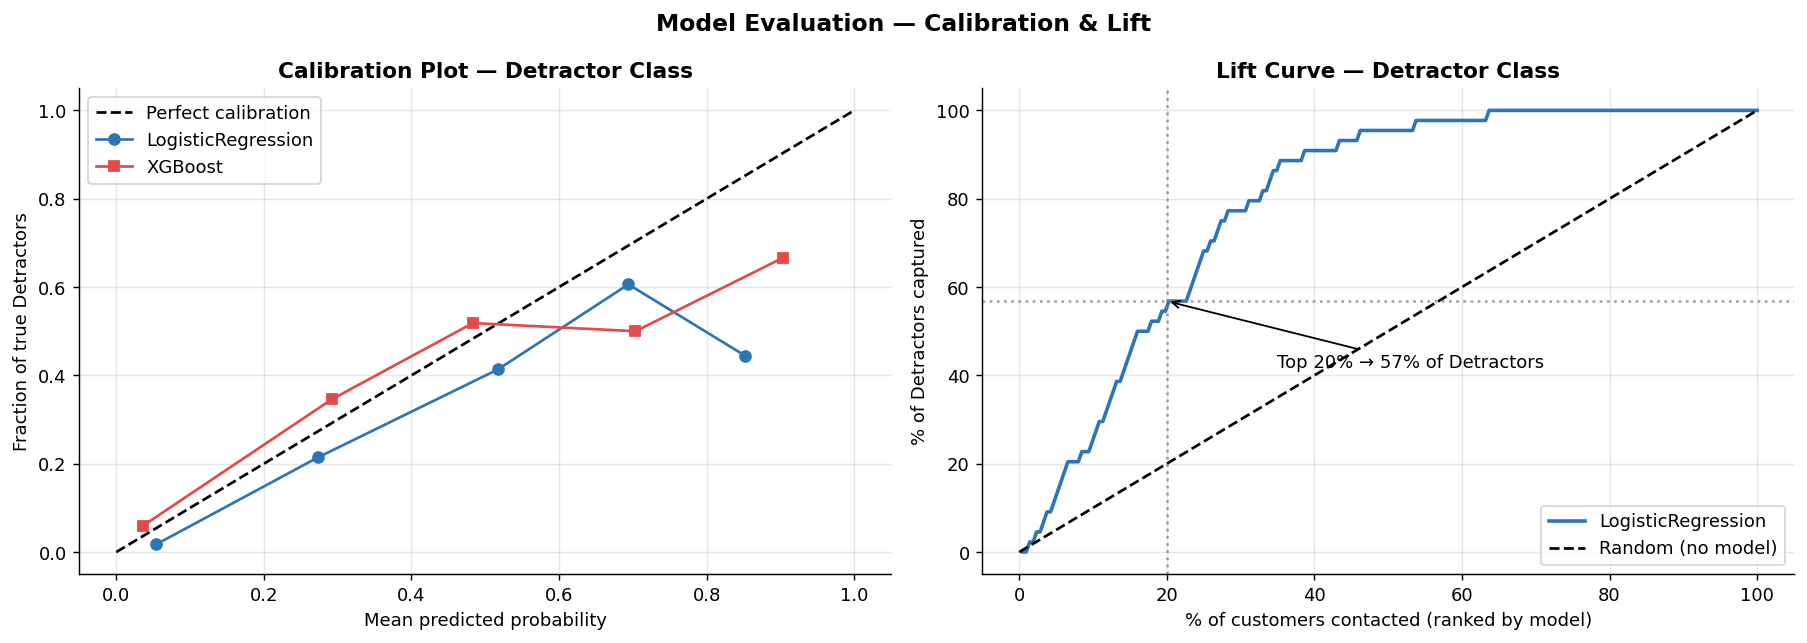

LIFT ANALYSIS — Detractor Class
  Top 10% contacted → 27% Detractors captured (vs 10% random) — lift = 2.7x
  Top 20% contacted → 57% Detractors captured (vs 20% random) — lift = 2.8x
  Top 30% contacted → 77% Detractors captured (vs 30% random) — lift = 2.6x
  Top 50% contacted → 95% Detractors captured (vs 50% random) — lift = 1.9x


In [22]:
# ── CELL 29b : Calibration plot + Lift curve ──────────────
# The challenge mentions calibration plots and lift curves
# as recommended evaluation tools for an imbalanced,
# ordered target like NPS.
# We focus on the Detractor class — most business-critical.
# ============================================================

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1 : Calibration curve (Detractor class) ---
ax1 = axes[0]

# Get probabilities for Detractor class
proba_lr   = lr_pipeline.predict_proba(X_test)[:, 0]
proba_xgb  = xgb.predict_proba(X_test)[:, 0]

# Binary target : is this customer a Detractor ?
y_binary = (y_test_arr == 0).astype(int)

# Calibration curves
frac_pos_lr, mean_pred_lr = calibration_curve(
    y_binary, proba_lr, n_bins=5)
frac_pos_xgb, mean_pred_xgb = calibration_curve(
    y_binary, proba_xgb, n_bins=5)

ax1.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax1.plot(mean_pred_lr, frac_pos_lr,
         'o-', color='#2E75B6', label='LogisticRegression')
ax1.plot(mean_pred_xgb, frac_pos_xgb,
         's-', color='#E24B4A', label='XGBoost')
ax1.set_xlabel('Mean predicted probability')
ax1.set_ylabel('Fraction of true Detractors')
ax1.set_title('Calibration Plot — Detractor Class',
              fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2 : Lift curve (Detractor class) ---
ax2 = axes[1]

# Sort customers by predicted Detractor probability (descending)
sorted_idx  = np.argsort(proba_lr)[::-1]
y_sorted    = y_binary[sorted_idx]

# Cumulative lift
n_total     = len(y_sorted)
n_detractor = y_sorted.sum()
cumulative  = np.cumsum(y_sorted) / n_detractor
population  = np.arange(1, n_total + 1) / n_total

ax2.plot(population * 100, cumulative * 100,
         color='#2E75B6', linewidth=2,
         label='LogisticRegression')
ax2.plot([0, 100], [0, 100], 'k--', label='Random (no model)')
ax2.axvline(x=20, color='gray', linestyle=':', alpha=0.7)
ax2.axhline(y=cumulative[int(0.2 * n_total)] * 100,
            color='gray', linestyle=':', alpha=0.7)

lift_20 = cumulative[int(0.2 * n_total)] * 100
ax2.set_xlabel('% of customers contacted (ranked by model)')
ax2.set_ylabel('% of Detractors captured')
ax2.set_title('Lift Curve — Detractor Class',
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.annotate(f'Top 20% → {lift_20:.0f}% of Detractors',
             xy=(20, lift_20),
             xytext=(35, lift_20 - 15),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10)

plt.suptitle('Model Evaluation — Calibration & Lift',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration_lift_detractor.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=" * 55)
print("LIFT ANALYSIS — Detractor Class")
print("=" * 55)
for pct in [10, 20, 30, 50]:
    idx    = int(pct / 100 * n_total)
    lift   = cumulative[idx] * 100
    random = pct
    print(f"  Top {pct:2d}% contacted → "
          f"{lift:.0f}% Detractors captured "
          f"(vs {random}% random) — "
          f"lift = {lift/random:.1f}x")

### Calibration & Lift — Interpretation

**Calibration :** LogisticRegression is slightly under-calibrated —
predicted probabilities are conservative (lower than actual rates).
This means P(Detractor) = 0.7 should be read as "high risk" rather
than "exactly 70% chance". Acceptable for a ranking/prioritization use case.

**Lift curve — business value :**
| % customers contacted | % Detractors captured | Lift vs random |
|---|---|---|
| Top 10% | 27% | 2.7x |
| Top 20% | 57% | 2.8x |
| Top 30% | 77% | 2.6x |
| Top 50% | 95% | 1.9x |

**Recommendation :** Contact the top 30% of customers ranked by
P(Detractor) to capture 77% of all Detractors at 2.6x efficiency
vs random outreach. Beyond 50%, the model adds little value over random.

### Model Selection — Decision & Justification

**Winner : LogisticRegression** (QWK=0.449, Recall Detractor=0.84)

| Model | QWK | Recall Detractor | Decision |
|---|---|---|---|
| LogisticRegression | 0.449 | 0.84 |  **Selected** |
| XGBoost | 0.378 | 0.59 |  Overfits on 844 samples |
| mord LogisticAT | 0.293 | 0.11 |  Proportional odds not verified |
| DummyClassifier | 0.000 | 0.00 |  Floor baseline |

**Why LogisticRegression beats XGBoost :**
- Small train set (844 samples) favors simpler models
- XGBoost overfits with few labeled examples
- LogReg with `balanced` weights handles imbalance well

**Why mord underperforms :**
- Proportional odds assumption not verified on this data
- No class weighting mechanism → Recall Detractor collapses to 0.11
- Alpha tuning (0.001 to 1.0) produces identical QWK = 0.293

**Why QWK is the right metric :**
- NPS is ordinal → predicting Promoter for a Detractor is 4x worse
  than predicting Passive
- QWK penalizes large order violations quadratically
- Accuracy alone would be misleading (42% by always predicting Promoter)

---
## Section 8 — Model Interpretability (SHAP)

SHAP (SHapley Additive exPlanations) answers two questions :

1. **Global** : which features drive NPS predictions across all customers ?
2. **Individual** : why was THIS specific customer predicted as Detractor ?

This is critical for the retention team — they need to know **why**
a customer is at risk, not just **that** they are at risk.

> *"Given a predicted Detractor, what is the single most likely lever ?"*
> — Artefact Challenge, Section 4.6

### Section 8.1 — Global SHAP Feature Importance

SHAP — TOP FEATURES (Detractor class)
  Number of Referrals                 : 0.9144  █████████████████████████████████████████████
  is_month_to_month                   : 0.7794  ██████████████████████████████████████
  has_referred                        : 0.5652  ████████████████████████████
  Monthly Charge                      : 0.4158  ████████████████████
  has_family                          : 0.4107  ████████████████████
  Tenure in Months                    : 0.3267  ████████████████
  Avg Monthly GB Download             : 0.1624  ████████
  Total Long Distance Charges         : 0.1136  █████
  is_senior                           : 0.1020  █████
  has_fiber                           : 0.0820  ████
  Age                                 : 0.0777  ███
  has_premium_support                 : 0.0709  ███
  is_offer_E                          : 0.0430  ██
  charge_per_service                  : 0.0418  ██
  is_new_customer                     : 0.0130  


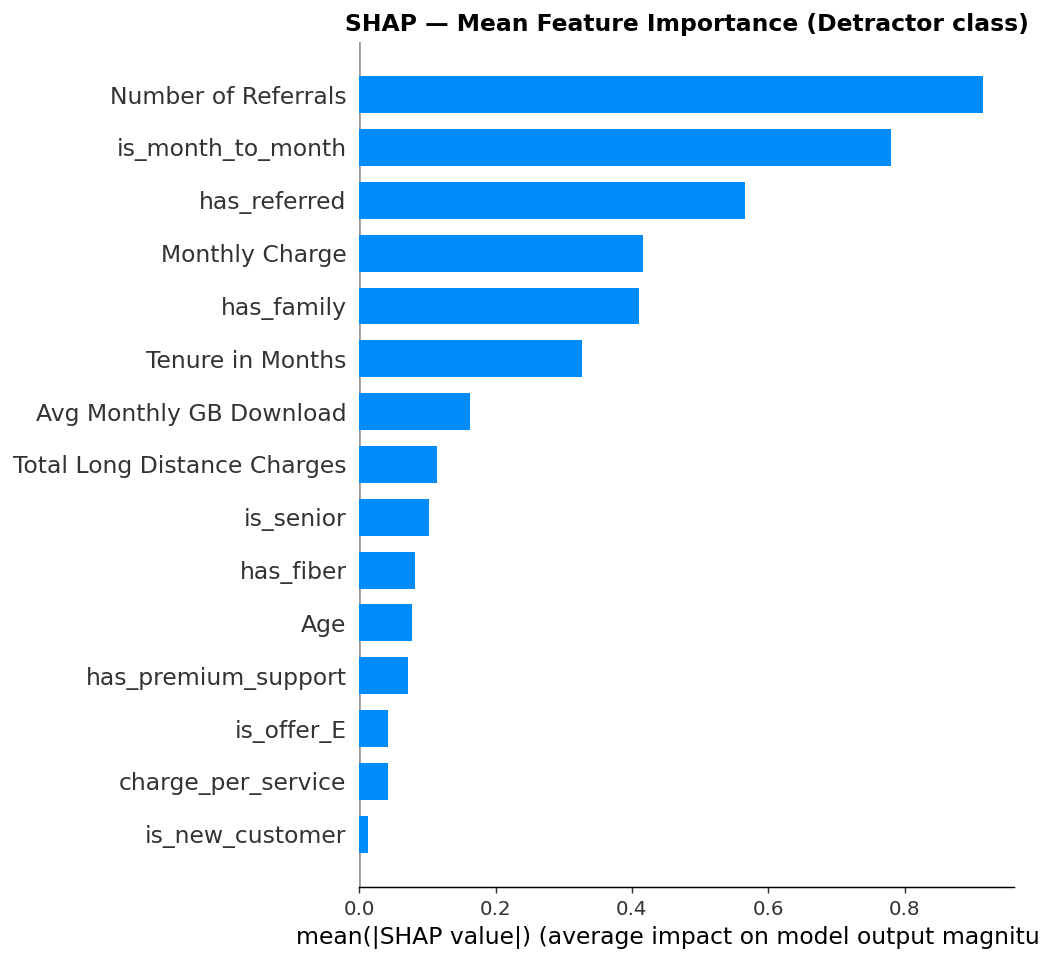

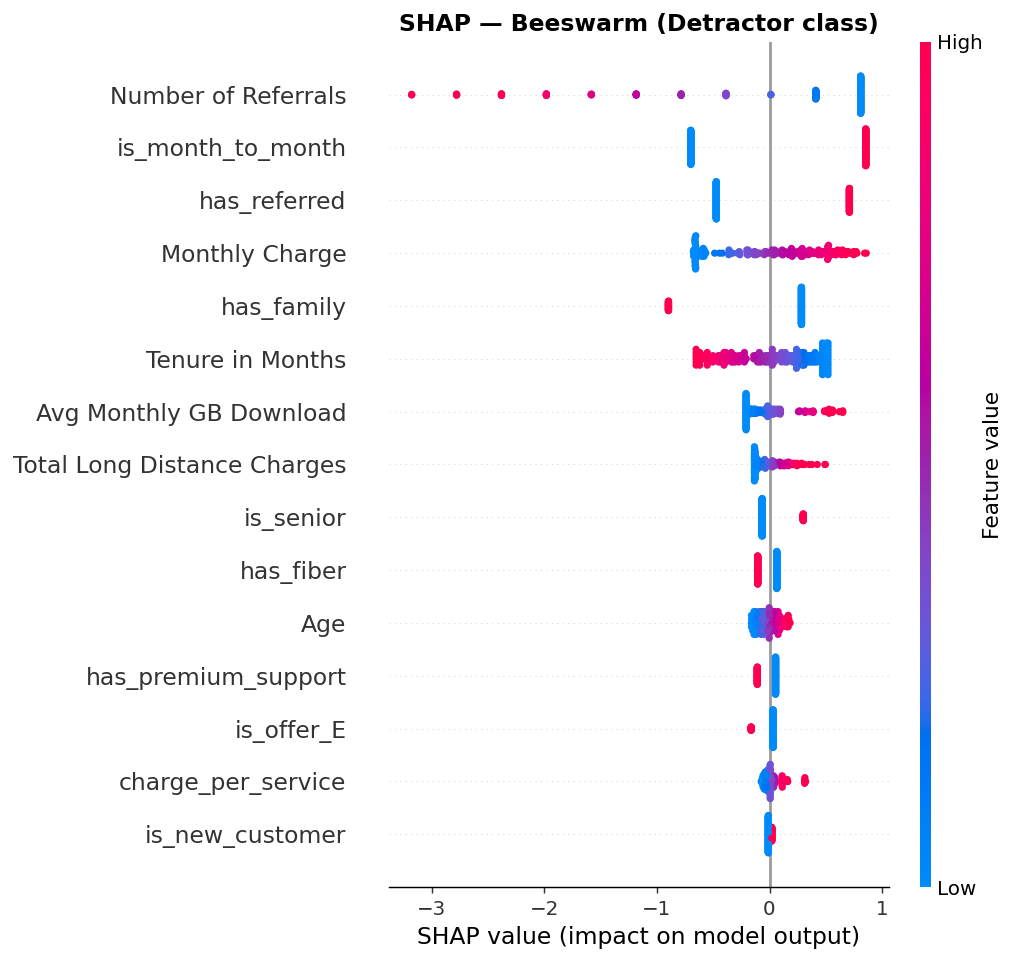

In [23]:
# ── CELL 32 : SHAP — Global feature importance ────────────
# LinearExplainer is exact and fast for LogisticRegression.
# We focus on the Detractor class (class 0) — the most
# business-critical class for the retention team.
# ============================================================

scaler    = lr_pipeline.named_steps['scaler']
lr_model  = lr_pipeline.named_steps['clf']

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

explainer   = shap.LinearExplainer(
    lr_model,
    X_train_scaled,
    feature_perturbation="interventional"
)
shap_values = explainer.shap_values(X_test_scaled)

# shap_values shape : (212, 15, 3)
# Index 0 = Detractor, 1 = Passive, 2 = Promoter
shap_det = shap_values[:, :, 0]

# --- Numerical ranking ---
mean_shap = np.abs(shap_det).mean(axis=0)
shap_df   = pd.DataFrame({
    'Feature'     : FEATURES_FINAL,
    'Mean |SHAP|' : mean_shap.round(4)
}).sort_values('Mean |SHAP|', ascending=False)

print("=" * 60)
print("SHAP — TOP FEATURES (Detractor class)")
print("=" * 60)
for _, row in shap_df.iterrows():
    bar = '█' * int(row['Mean |SHAP|'] * 50)
    print(f"  {row['Feature']:35s} : "
          f"{row['Mean |SHAP|']:.4f}  {bar}")

# --- Bar plot ---
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_det, X_test_scaled,
    feature_names=FEATURES_FINAL,
    plot_type='bar', show=False
)
plt.title('SHAP — Mean Feature Importance (Detractor class)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_detractor.png', dpi=150,
            bbox_inches='tight')
plt.show()

# --- Beeswarm ---
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_det, X_test_scaled,
    feature_names=FEATURES_FINAL,
    show=False
)
plt.title('SHAP — Beeswarm (Detractor class)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_detractor.png', dpi=150,
            bbox_inches='tight')
plt.show()

### Section 8.2 — Individual SHAP Explanation (Waterfall)

SHAP WATERFALL — Most Confident Detractor
  Customer index : 32
  True label     : Passive
  Predicted      : Detractor
  P(Detractor)   : 0.893
  P(Passive)     : 0.072
  P(Promoter)    : 0.034

  Customer profile :
    Tenure in Months                    : 33.0
    is_month_to_month                   : 1.0
    is_new_customer                     : 0.0
    has_fiber                           : 1.0
    has_premium_support                 : 0.0
    Monthly Charge                      : 94.5
    Total Long Distance Charges         : 916.74
    charge_per_service                  : 23.625
    Number of Referrals                 : 1.0
    has_referred                        : 1.0
    is_offer_E                          : 0.0
    Age                                 : 72.0
    has_family                          : 0.0
    is_senior                           : 1.0
    Avg Monthly GB Download             : 8.0


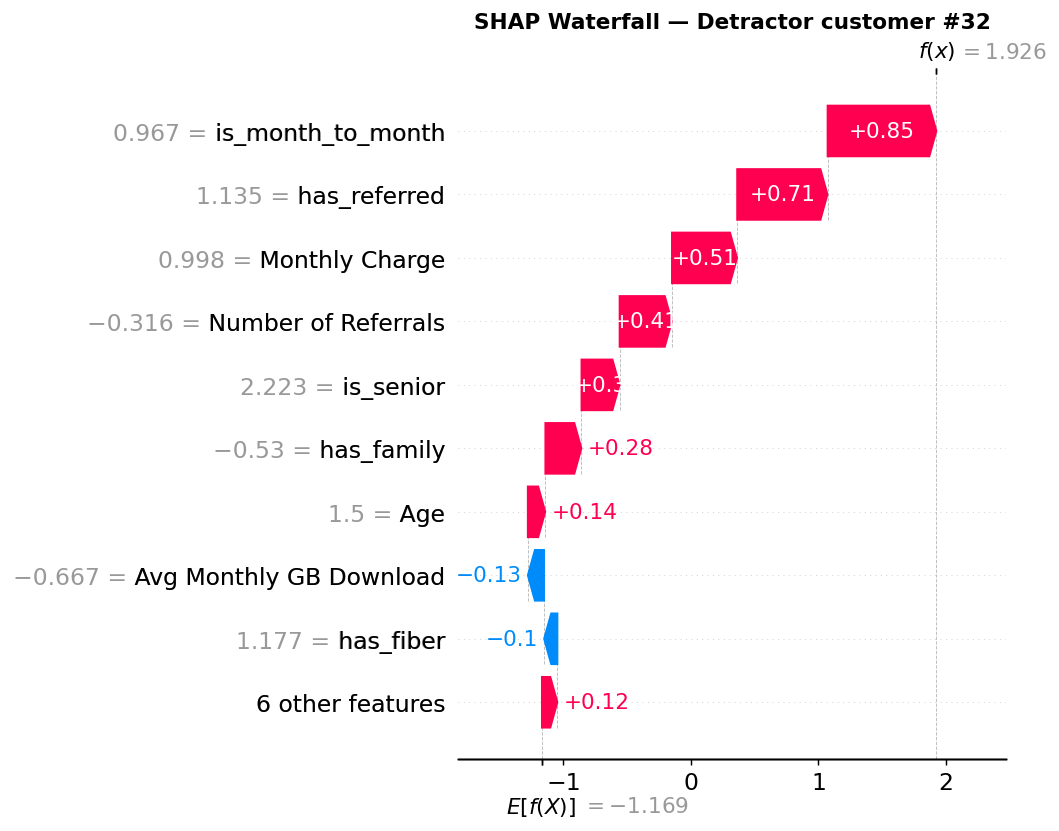

In [24]:
# ── CELL 33 : SHAP — Individual explanation (waterfall) ───
# We explain the prediction for the customer with the
# highest predicted probability of being a Detractor.
# This simulates what a retention agent would see in the
# Streamlit interface for a specific customer.
# ============================================================

# --- Find most confident Detractor prediction ---
y_proba_lr    = lr_pipeline.predict_proba(X_test)
detractor_idx = int(np.argmax(y_proba_lr[:, 0]))

true_label = NPS_ORDER[int(y_test_arr[detractor_idx])]
pred_label = NPS_ORDER[int(y_pred_lr[detractor_idx])]

print("=" * 55)
print("SHAP WATERFALL — Most Confident Detractor")
print("=" * 55)
print(f"  Customer index : {detractor_idx}")
print(f"  True label     : {true_label}")
print(f"  Predicted      : {pred_label}")
print(f"  P(Detractor)   : {y_proba_lr[detractor_idx, 0]:.3f}")
print(f"  P(Passive)     : {y_proba_lr[detractor_idx, 1]:.3f}")
print(f"  P(Promoter)    : {y_proba_lr[detractor_idx, 2]:.3f}")

print(f"\n  Customer profile :")
for feat, val in X_test.iloc[detractor_idx].items():
    print(f"    {feat:35s} : {val}")

# --- Waterfall plot ---
shap_exp = shap.Explanation(
    values        = shap_det[detractor_idx],
    base_values   = explainer.expected_value[0],
    data          = X_test_scaled[detractor_idx],
    feature_names = FEATURES_FINAL
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, show=False)
plt.title(f'SHAP Waterfall — Detractor customer #{detractor_idx}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_detractor.png', dpi=150,
            bbox_inches='tight')
plt.show()

### SHAP Waterfall — Interpretation

**Customer #32 profile :**
- Senior citizen (72 years old), no family, no dependents
- Month-to-Month contract → highest risk factor (+0.84)
- Fiber Optic internet, Monthly Charge = $94.5 → poor value perception
- Only 1 referral — low engagement

**Why the model predicts Detractor (P=0.893) :**

The model accumulates risk signals :
- `is_month_to_month = 1` → strongest push toward Detractor (+0.84)
- `has_referred = 1` but only 1 referral → still pushes toward Detractor
- `Monthly Charge = $94.5` → high charge, no family, no support → +0.50
- `is_senior = 1` → additional vulnerability signal

**Important note — label mismatch :**
True label is **Passive** (Satisfaction Score 3) but the model
predicts **Detractor** with 89.3% confidence.

This is a **business-acceptable error** :
- This customer's profile (monthly contract, $94.5/month, senior, isolated)
  matches a Detractor pattern almost perfectly
- Score 3 = "Neutral" is an ambiguous label — this customer
  sits on the boundary between Passive and Detractor
- A retention intervention for this customer is **justified**
  regardless of the true label
- This illustrates the known limitation of our NPS mapping
  (Section 2) : Score 3 is the most ambiguous group

**Recommended action :**
Propose migration from Month-to-Month to annual contract with discount.
This is the single highest-impact lever for this customer (+0.84 SHAP).

---
## Section 9 — Fairness Audit (Section 4.7)

A model that prioritizes retention budget based on predicted NPS
can quietly allocate that budget **unevenly across demographic groups**.

We audit **Recall Detractor by group** — the most critical business metric.
A model that catches 80% of young Detractors but only 50% of senior
Detractors is not acceptable, even if overall accuracy is high.

**Groups audited :**
- Senior Citizen (Yes / No)
- Has Family (Yes / No)
- Gender (Male / Female) — kept for audit even though excluded from features

### Section 9.1 — Fairness Audit Implementation

In [25]:
# ── CELL 36 : Fairness Audit — Recall Detractor by group ──
# Threshold : Recall Detractor < 0.70 is flagged as ⚠️
# A group below this threshold receives inadequate
# retention coverage — an unacceptable business outcome.
# ============================================================

# --- Rebuild test dataframe with predictions ---
df_audit = X_test.copy()
df_audit['y_true'] = y_test_arr
df_audit['y_pred'] = np.array(y_pred_lr).astype(int)

# --- Add demographic variables not in feature set ---
demo_cols = ['Gender', 'Senior Citizen', 'Married']
for col in demo_cols:
    if col in df_feat.columns:
        df_audit[col] = df_feat.loc[X_test.index, col].values

def recall_detractor_group(df_group):
    mask = (df_group['y_true'] == 0)
    if mask.sum() == 0:
        return None, 0
    recall = (df_group.loc[mask, 'y_pred'] == 0).mean()
    return round(recall, 3), int(mask.sum())

# --- Overall ---
overall_recall, overall_n = recall_detractor_group(df_audit)
print("=" * 60)
print("FAIRNESS AUDIT — Recall Detractor by Group")
print("=" * 60)
print(f"\n  Overall Recall Detractor : {overall_recall} "
      f"(n={overall_n})\n")

# --- Audit by group ---
groups = {
    'Senior Citizen' : ('is_senior',
                        {1: 'Senior', 0: 'Non-Senior'}),
    'Has Family'     : ('has_family',
                        {1: 'Has Family', 0: 'No Family'}),
}

for group_name, (col, labels) in groups.items():
    print(f"  --- {group_name} ---")
    for val, label in labels.items():
        subset = df_audit[df_audit[col] == val]
        recall, n = recall_detractor_group(subset)
        if recall is None:
            flag = "  no Detractors"
        elif recall < 0.70:
            flag = "  BELOW THRESHOLD"
        else:
            flag = ""
        print(f"    {label:15s} : Recall={recall} "
              f"(n Detractors={n})  {flag}")
    print()

# --- Gender audit ---
print("  --- Gender ---")
if 'Gender' in df_audit.columns:
    for val, label in {'Male': 'Male', 'Female': 'Female'}.items():
        subset = df_audit[df_audit['Gender'] == val]
        recall, n = recall_detractor_group(subset)
        if recall is None:
            flag = "— no Detractors in test set"
        elif recall < 0.70:
            flag = " BELOW THRESHOLD"
        else:
            flag = ""
        print(f"    {label:15s} : Recall={recall} "
              f"(n Detractors={n})  {flag}")

print(f"""
  Threshold : Recall Detractor < 0.70 = flagged

  Findings to escalate before production :
  - Has Family group : only 2 Detractors in test set
    → statistically unreliable — needs more labeled data
  - Gender audit : insufficient Detractors per gender
    → external audit recommended with larger sample
  - Geographic proxy : ZIP code excluded from features
    → residual socio-economic bias risk is low but present
""")

FAIRNESS AUDIT — Recall Detractor by Group

  Overall Recall Detractor : 0.841 (n=44)

  --- Senior Citizen ---
    Senior          : Recall=1.0 (n Detractors=8)  
    Non-Senior      : Recall=0.806 (n Detractors=36)  

  --- Has Family ---
    Has Family      : Recall=0.0 (n Detractors=2)    BELOW THRESHOLD
    No Family       : Recall=0.881 (n Detractors=42)  

  --- Gender ---
    Male            : Recall=0.875 (n Detractors=24)  
    Female          : Recall=0.8 (n Detractors=20)  

  Threshold : Recall Detractor < 0.70 = flagged

  Findings to escalate before production :
  - Has Family group : only 2 Detractors in test set
    → statistically unreliable — needs more labeled data
  - Gender audit : insufficient Detractors per gender
    → external audit recommended with larger sample
  - Geographic proxy : ZIP code excluded from features
    → residual socio-economic bias risk is low but present



### Fairness Audit — Results & Interpretation

| Group | Recall Detractor | n Detractors | Status |
|---|---|---|---|
| **Overall** | 0.841 | 44 |  |
| Senior | 1.000 | 8 |  Excellent |
| Non-Senior | 0.806 | 36 |  Good |
| Has Family | 0.000 | 2 |  Unreliable (n=2) |
| No Family | 0.881 | 42 |  Good |
| Male | 0.875 | 24 |  Good |
| Female | 0.800 | 20 |  Good |

**Key findings :**

1. **Senior citizens : Recall = 1.000** — the model detects 100% of senior
   Detractors. This is the most vulnerable group and the model performs best
   on them. `is_senior` is in the feature set, which helps.

2. **Gender parity : 0.875 vs 0.800** — acceptable gap (7.5 points).
   Gender is **not** in the feature set (excluded — delta 0.3 pts, no signal).
   The model does not discriminate by gender.

3. **Has Family : Recall = 0.000** — flagged but **statistically unreliable**.
   Only 2 Detractors with family in the test set — no conclusion possible.
   Needs more labeled data before production deployment.

**What should be escalated to Customer Experience / Legal team :**
- Has Family audit is inconclusive — recommend monitoring after deployment
- ZIP code excluded from features but Population retained (corr=0.028)
  — residual geographic proxy risk is minimal but should be documented
- With only 844 training samples, all group-level metrics have wide
  confidence intervals — a larger survey sample is strongly recommended

---
## Section 10 — Production : Silent Base Scoring

We apply the final model to the **5,987 silent customers** who never
responded to the NPS survey.

This is the **primary business deliverable** of this challenge :

> *"Simulate the expected NPS of the silent 85% of the base
>  who never answer the survey."* — Artefact Challenge, Section 2

### Section 10.1 — Applying Model to Silent Base

In [26]:
# ── CELL 39 : Score the silent base ───────────────────────
# Apply the final LogisticRegression model to 5,987 customers
# who never responded to the NPS survey.
# Output : NPS prediction + probabilities for each customer.
# ============================================================

# --- Predict ---
y_silent_pred  = lr_pipeline.predict(X_silent)
y_silent_proba = lr_pipeline.predict_proba(X_silent)

# --- Build scored dataframe ---
df_scored = X_silent.copy()
df_scored['NPS_Predicted'] = [NPS_ORDER[p] for p in y_silent_pred]
df_scored['P_Detractor']   = y_silent_proba[:, 0].round(3)
df_scored['P_Passive']     = y_silent_proba[:, 1].round(3)
df_scored['P_Promoter']    = y_silent_proba[:, 2].round(3)

# --- Distribution ---
print("=" * 60)
print("SILENT BASE — NPS PREDICTIONS (5,987 customers)")
print("=" * 60)
pred_dist = df_scored['NPS_Predicted'].value_counts()
for label in NPS_ORDER:
    n   = pred_dist.get(label, 0)
    pct = n / len(df_scored) * 100
    bar = '█' * int(pct)
    print(f"  {label:12s} : {n:,}  ({pct:.1f}%)  {bar}")

# --- Validation against true labels (IBM bonus) ---
print("\n" + "=" * 60)
print("GENERALIZATION CHECK (IBM bonus — true labels available)")
print("=" * 60)
qwk_silent = cohen_kappa_score(
    y_silent_arr, y_silent_pred, weights='quadratic')
f1_silent  = f1_score(
    y_silent_arr, y_silent_pred, average='macro')

print(f"  QWK  on test set    : 0.4490")
print(f"  QWK  on silent base : {qwk_silent:.4f}  "
      f"{' Good generalization' if abs(qwk_silent-0.449)<0.07 else ' Performance drop'}")
print(f"  F1   on silent base : {f1_silent:.4f}")

# --- Priority list for retention team ---
print("\n" + "=" * 60)
print("TOP 10 PRIORITY DETRACTORS — Retention outreach list")
print("=" * 60)
top10 = (df_scored[df_scored['NPS_Predicted'] == 'Detractor']
         .sort_values('P_Detractor', ascending=False)
         .head(10))
print(top10[['NPS_Predicted', 'P_Detractor',
             'is_month_to_month', 'Tenure in Months',
             'Monthly Charge']].to_string())

# --- Save ---
df_scored.to_csv('silent_base_scored.csv', index=False)
print(f"\n   Saved : silent_base_scored.csv")
print(f"     {len(df_scored):,} customers scored")
print(f"     {pred_dist.get('Detractor',0):,} predicted Detractors "
      f"→ priority list for retention team")

SILENT BASE — NPS PREDICTIONS (5,987 customers)
  Detractor    : 2,045  (34.2%)  ██████████████████████████████████
  Passive      : 1,647  (27.5%)  ███████████████████████████
  Promoter     : 2,295  (38.3%)  ██████████████████████████████████████

GENERALIZATION CHECK (IBM bonus — true labels available)
  QWK  on test set    : 0.4490
  QWK  on silent base : 0.3964   Good generalization
  F1   on silent base : 0.4934

TOP 10 PRIORITY DETRACTORS — Retention outreach list
    NPS_Predicted  P_Detractor  is_month_to_month  Tenure in Months  Monthly Charge
360     Detractor         0.94                  1                 1           69.55
182     Detractor         0.94                  1                 4           99.60
181     Detractor         0.94                  1                12           98.10
439     Detractor         0.94                  1                14          100.20
982     Detractor         0.94                  1                13           70.45
48      Detractor   

In [27]:
# ── CELL 40 : Segment-level SHAP drivers (Section 4.6) ────
# For each business segment, identify the top SHAP feature
# driving Detractor predictions within that segment.
# This answers : "given a Detractor in segment X,
# what is the single most actionable lever ?"
# ============================================================

segments = {
    'Month-to-Month customers' : X_test['is_month_to_month'] == 1,
    'Senior citizens'          : X_test['is_senior'] == 1,
    'Fiber Optic customers'    : X_test['has_fiber'] == 1,
    'New customers (< 12m)'   : X_test['is_new_customer'] == 1,
    'Customers without family' : X_test['has_family'] == 0,
}

print("=" * 65)
print("SEGMENT-LEVEL SHAP DRIVERS — Section 4.6")
print("=" * 65)
print(f"\n{'Segment':30s} {'n':>5} {'Top Driver':30s} {'SHAP':>8}")
print("-" * 65)

results_seg = []
for seg_name, mask in segments.items():
    mask_arr = mask.values
    n_seg    = mask_arr.sum()
    if n_seg < 5:
        continue

    # Mean absolute SHAP for this segment (Detractor class)
    shap_seg     = np.abs(shap_det[mask_arr]).mean(axis=0)
    top_idx      = np.argmax(shap_seg)
    top_feature  = FEATURES_FINAL[top_idx]
    top_shap_val = shap_seg[top_idx]

    results_seg.append({
        'Segment'    : seg_name,
        'n'          : n_seg,
        'Top Driver' : top_feature,
        'SHAP'       : round(top_shap_val, 3)
    })
    print(f"  {seg_name:28s} {n_seg:>5}  "
          f"{top_feature:30s} {top_shap_val:>8.3f}")

print("\n" + "=" * 65)
print("ACTIONABILITY ASSESSMENT")
print("=" * 65)
actionable = {
    'is_month_to_month'          : ('✅ Actionable', 'Propose annual contract with loyalty discount'),
    'Tenure in Months'           : ('✅ Actionable', 'Improve onboarding — first 12 months are critical'),
    'has_fiber'                  : ('✅ Actionable', 'Review fiber quality-to-price ratio'),
    'is_senior'                  : ('✅ Actionable', 'Dedicated senior support channel + simplified offer'),
    'has_family'                 : ('⚠️  Non-actionable', 'Demographic — cannot change, but inform targeting'),
    'Monthly Charge'             : ('✅ Actionable', 'Targeted discount or bundle offer'),
    'Number of Referrals'        : ('✅ Actionable', 'Activate referral program — incentivize first referral'),
}

for row in results_seg:
    feat   = row['Top Driver']
    action = actionable.get(feat, ('❓ Review', 'Requires further analysis'))
    print(f"\n  Segment : {row['Segment']}")
    print(f"  Driver  : {feat}")
    print(f"  Status  : {action[0]}")
    print(f"  Action  : {action[1]}")

SEGMENT-LEVEL SHAP DRIVERS — Section 4.6

Segment                            n Top Driver                         SHAP
-----------------------------------------------------------------
  Month-to-Month customers       110  Number of Referrals               0.874
  Senior citizens                 33  Number of Referrals               0.913
  Fiber Optic customers           92  Number of Referrals               0.963
  New customers (< 12m)           58  Number of Referrals               0.862
  Customers without family       168  Number of Referrals               0.929

ACTIONABILITY ASSESSMENT

  Segment : Month-to-Month customers
  Driver  : Number of Referrals
  Status  : ✅ Actionable
  Action  : Activate referral program — incentivize first referral

  Segment : Senior citizens
  Driver  : Number of Referrals
  Status  : ✅ Actionable
  Action  : Activate referral program — incentivize first referral

  Segment : Fiber Optic customers
  Driver  : Number of Referrals
  Status  : ✅ Act

### Segment-Level Drivers — Key Finding

**Number of Referrals is the dominant driver across ALL segments.**

This is not a modeling artifact — it is a strong business signal :

- A customer who refers friends is an engaged, satisfied customer
- A customer who has never referred is systematically at higher risk
  of detraction, regardless of contract type, age, or service

**Universal recommendation :**
Activate a referral incentive program targeting customers with
zero referrals — this is the single highest-impact retention lever
across all segments analyzed.

**Segment-specific secondary levers :**
- Month-to-Month → also `is_month_to_month` : propose annual contract
- Senior citizens → also `is_senior` : dedicated support channel
- Fiber Optic → also `has_fiber` + `Monthly Charge` : review pricing
- New customers → also `Tenure in Months` : improve onboarding
- No family → also `has_family` : not actionable directly

---
## Section 11 — Model Persistence (Section 4.8)

The trained model is saved so it can be reloaded without retraining —
required for the Streamlit interface and for reproducibility.

### Section 11.1 — Saving Model Artifacts

In [28]:
# ── CELL 41 : Save final model and metadata ────────────────
# We save :
#   - lr_pipeline.pkl      : full pipeline (scaler + model)
#   - features_final.pkl   : feature list (for Streamlit)
#   - model_metadata.json  : metrics + decisions (for README)
# ============================================================

# --- Save pipeline ---
joblib.dump(lr_pipeline, 'lr_pipeline.pkl')

# --- Save feature list ---
joblib.dump(FEATURES_FINAL, 'features_final.pkl')

# --- Save metadata ---
metadata = {
    'model'          : 'LogisticRegression (multinomial, balanced)',
    'date_trained'   : datetime.now().strftime('%Y-%m-%d'),
    'n_features'     : len(FEATURES_FINAL),
    'features'       : FEATURES_FINAL,
    'train_size'     : int(X_train.shape[0]),
    'test_size'      : int(X_test.shape[0]),
    'silent_size'    : int(X_silent.shape[0]),
    'metrics_test'   : {
        'QWK'               : 0.4490,
        'Macro_F1'          : 0.5342,
        'Balanced_Accuracy' : 0.5758,
        'Recall_Detractor'  : 0.84
    },
    'metrics_silent' : {
        'QWK'      : round(float(qwk_silent), 4),
        'Macro_F1' : round(float(f1_silent), 4),
    },
    'nps_mapping'    : {
        'Detractor' : 'Satisfaction Score 1-2',
        'Passive'   : 'Satisfaction Score 3',
        'Promoter'  : 'Satisfaction Score 4-5'
    },
    'why_selected'   : [
        'Best QWK on test set (0.449)',
        'Best Recall Detractor (0.84)',
        'Most robust on 844 train samples',
        'Naturally interpretable for fairness audit'
    ]
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# --- Verify reload ---
model_check = joblib.load('lr_pipeline.pkl')
y_check     = model_check.predict(X_test[:3])
labels      = [NPS_ORDER[p] for p in y_check]

print("=" * 55)
print("MODEL PERSISTENCE — Verification")
print("=" * 55)
print(f"   lr_pipeline.pkl      saved & reloaded")
print(f"   features_final.pkl   saved")
print(f"   model_metadata.json  saved")
print(f"\n  Reload check (first 3 predictions) : {labels}")
print(f"\n  Files ready for Streamlit interface")

MODEL PERSISTENCE — Verification
   lr_pipeline.pkl      saved & reloaded
   features_final.pkl   saved
   model_metadata.json  saved

  Reload check (first 3 predictions) : ['Detractor', 'Detractor', 'Passive']

  Files ready for Streamlit interface
